# eda 열연공정 part 1

## 열연공정 1

<Axes: ylabel='ap_line_speed'>

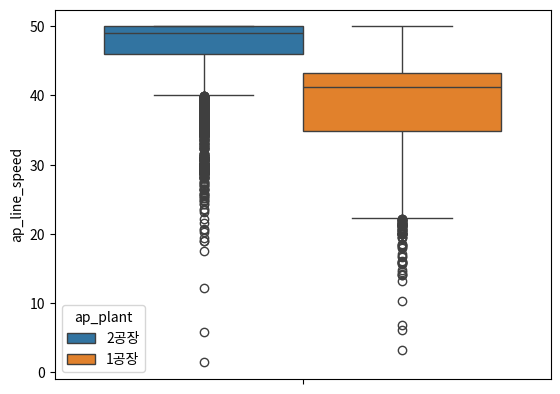

In [ ]:
sns.boxplot(data=final_df, hue = 'ap_plant', y = 'ap_line_speed')

In [ ]:
# sns.countplot(data=final_df, hue='furnace_no', x='judge')

In [ ]:
# cat_cols = ['furnace_no', 'f_jangip_gubun','hr_thick_group']

# plt.figure(figsize=(12, 5))

# for i, col in enumerate(cat_cols, 1):
#     plt.subplot(1, 3, i)
#     sns.countplot(data=final_df, x=col, hue='judge')
#     plt.title(f'{col} by judge')
#     plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()

In [ ]:
# sns.countplot(data=final_df, x = 'f_jangip_gubun')

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# cat_cols = ['furnace_no', 'f_jangip_gubun', 'hr_thick_group']

# # 불량 데이터만 추출
# bad_df = final_df[final_df['judge'] == '불량'].copy()

# for col in cat_cols:
#     count_df = (
#         bad_df[col]
#         .value_counts(dropna=False)
#         .reset_index()
#     )
#     count_df.columns = [col, 'bad_count']

#     # furnace_no만 호기 순서대로 정렬
#     if col == 'furnace_no':
#         furnace_order = ['1호기', '2호기', '3호기', '4호기']
#         count_df[col] = pd.Categorical(count_df[col], categories=furnace_order, ordered=True)
#         count_df = count_df.sort_values(col)

#     plt.figure(figsize=(8, 5))
#     ax = sns.barplot(data=count_df, x=col, y='bad_count',hue = col)

#     for i, v in enumerate(count_df['bad_count']):
#         ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

#     plt.title(f'{col}별 불량 개수')
#     plt.ylabel('Bad Count')
#     plt.xlabel(col)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

#     print(f'\n[{col}]')
#     print(count_df)
#     print('총 불량 개수:', count_df['bad_count'].sum())

## 연속형변수 boxplot

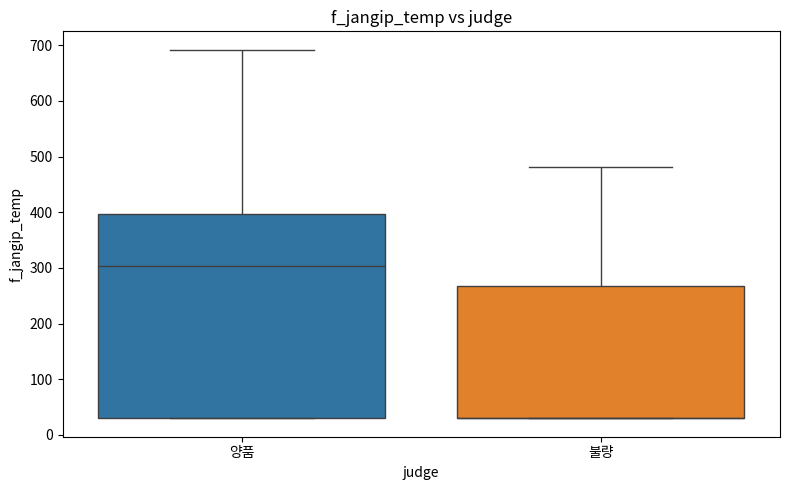

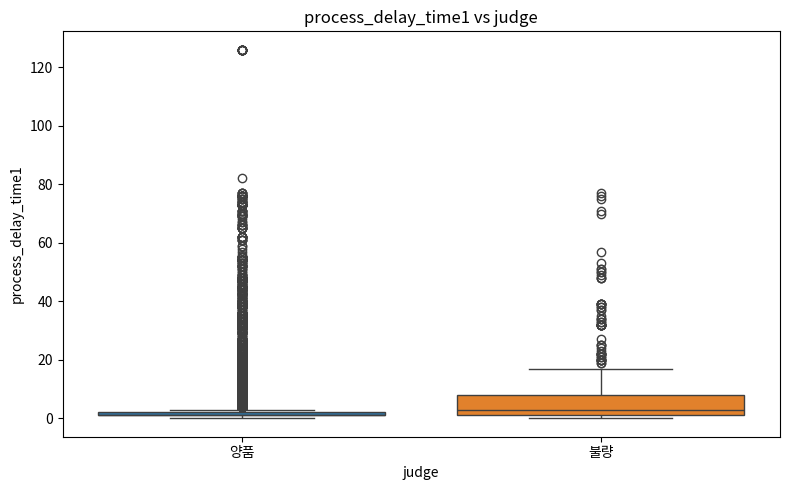

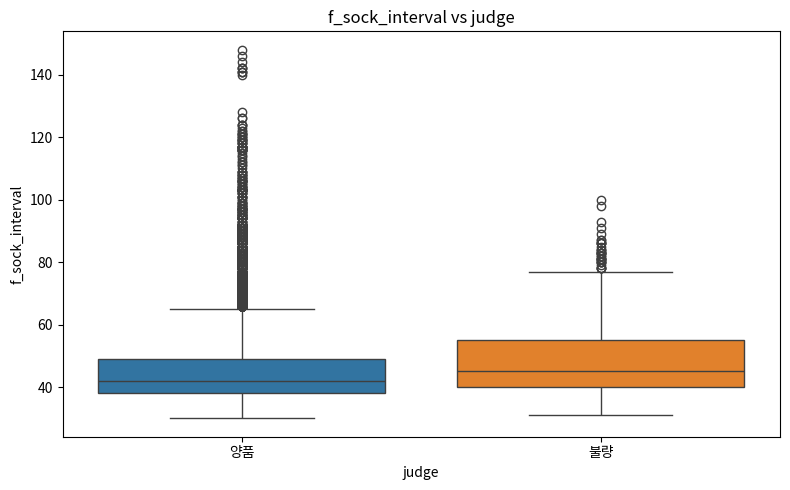

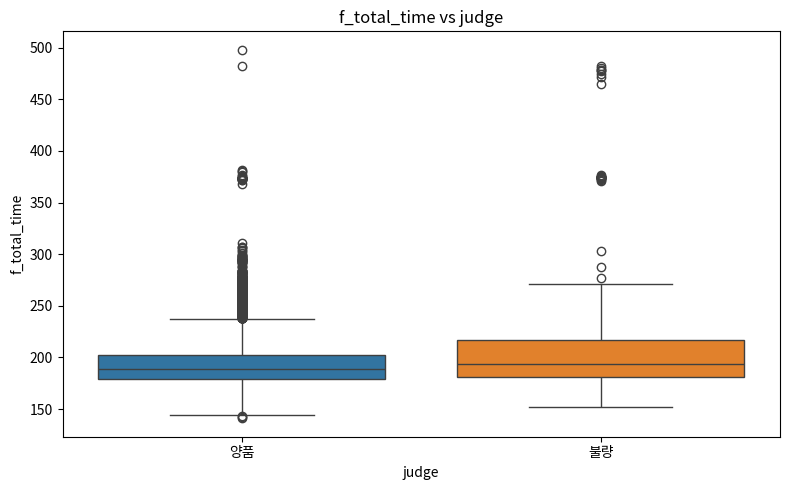

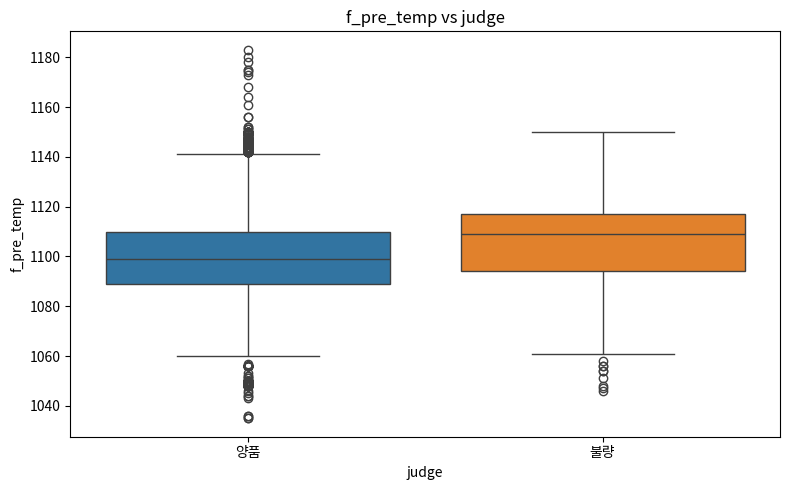

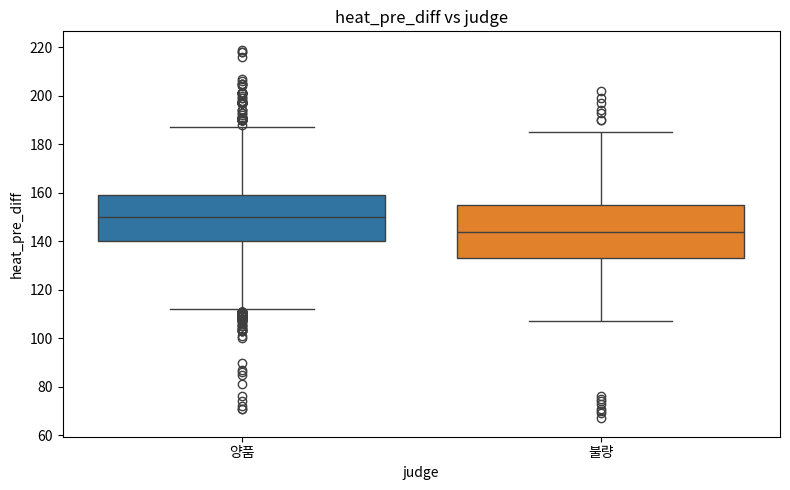

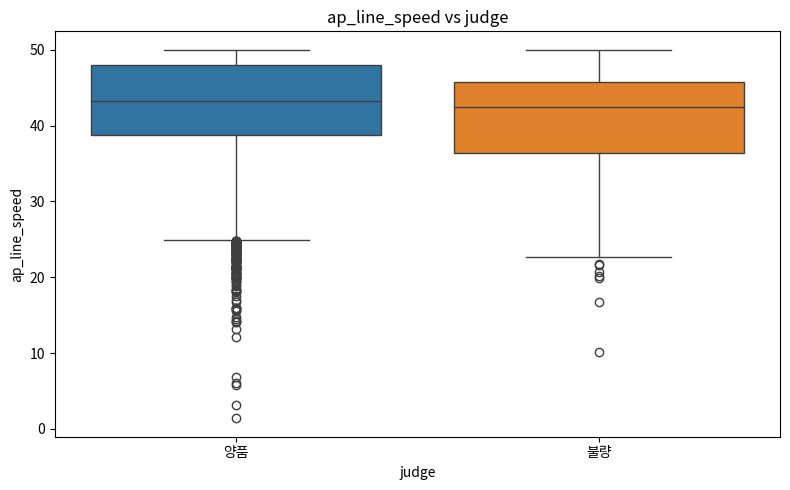

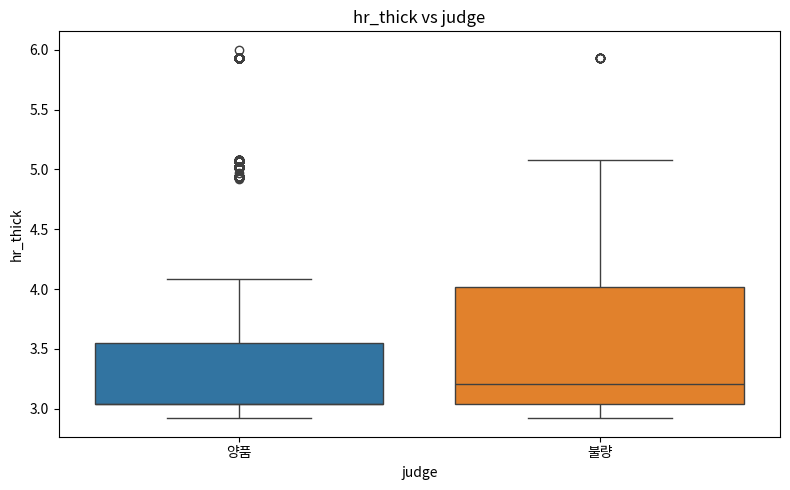

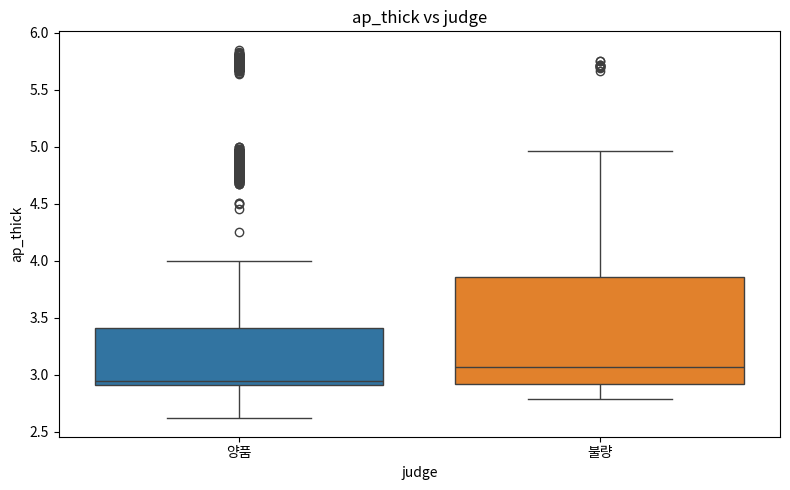

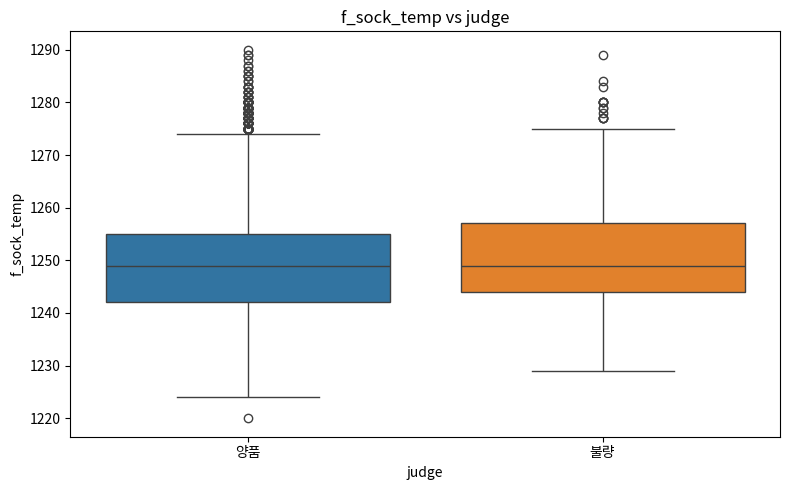

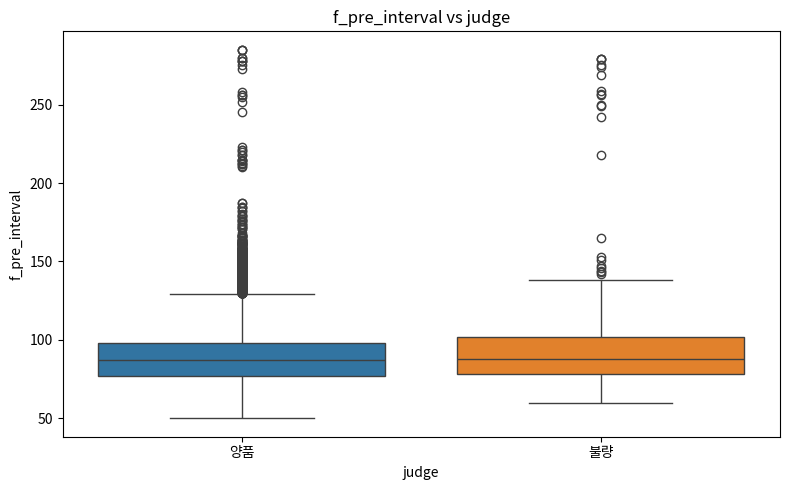

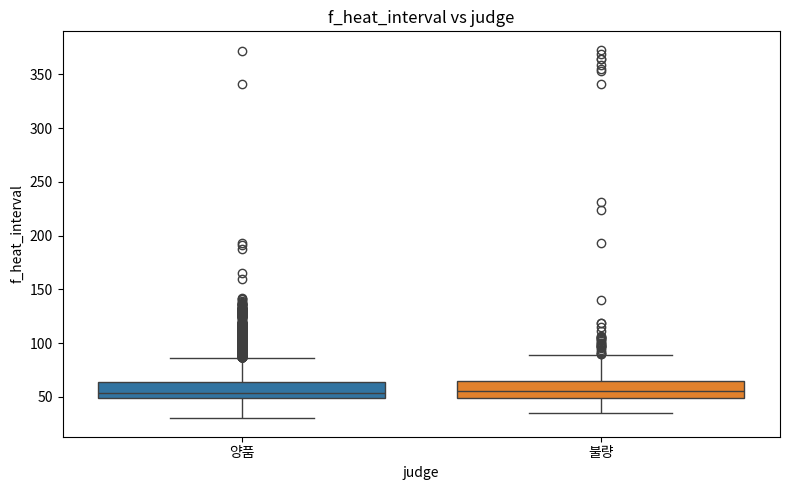

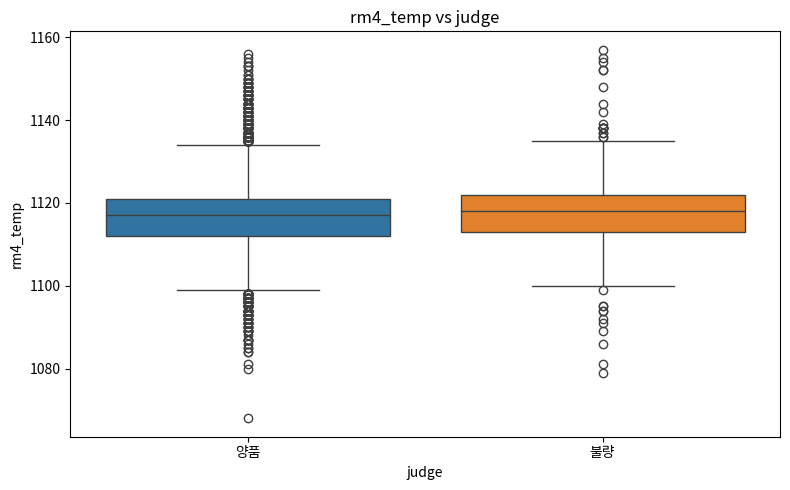

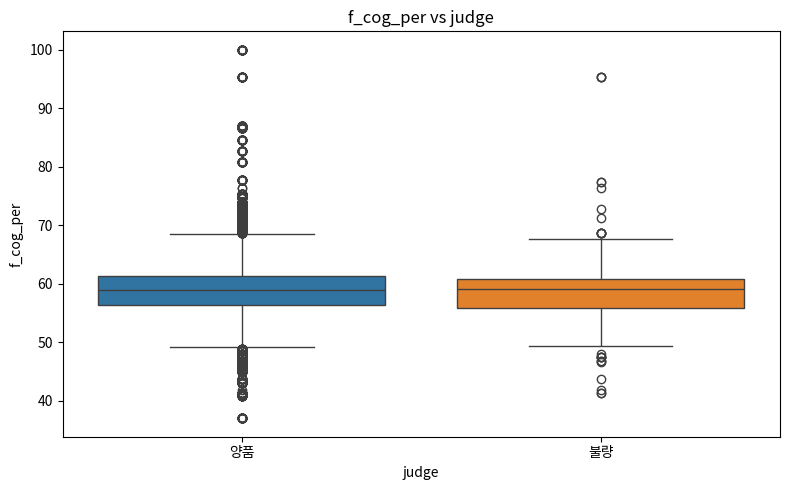

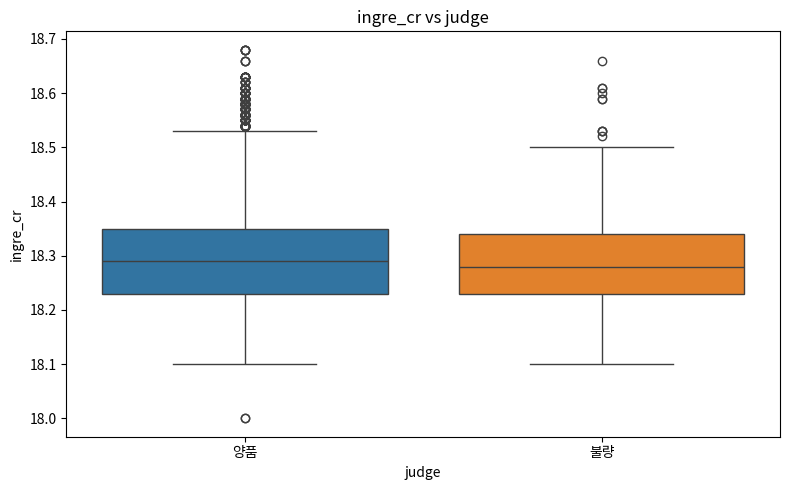

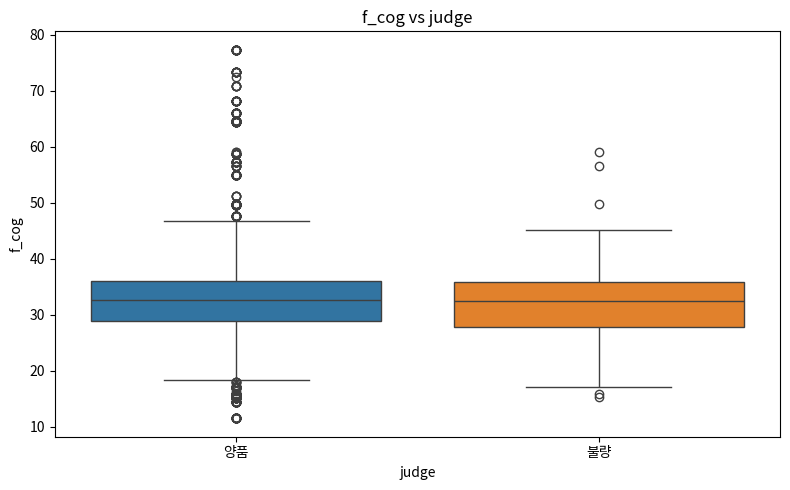

In [ ]:
# 유의 연속형 변수 박스플랏
num_cols = ['f_jangip_temp','process_delay_time1','f_sock_interval',
            'f_total_time','f_pre_temp','heat_pre_diff',
            'ap_line_speed','hr_thick','ap_thick','f_sock_temp',
            'f_pre_interval','f_heat_interval','rm4_temp',
            'f_cog_per','ingre_cr','f_cog']

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=final_df, x='judge', y=col, hue = 'judge')
    plt.title(f'{col} vs judge')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

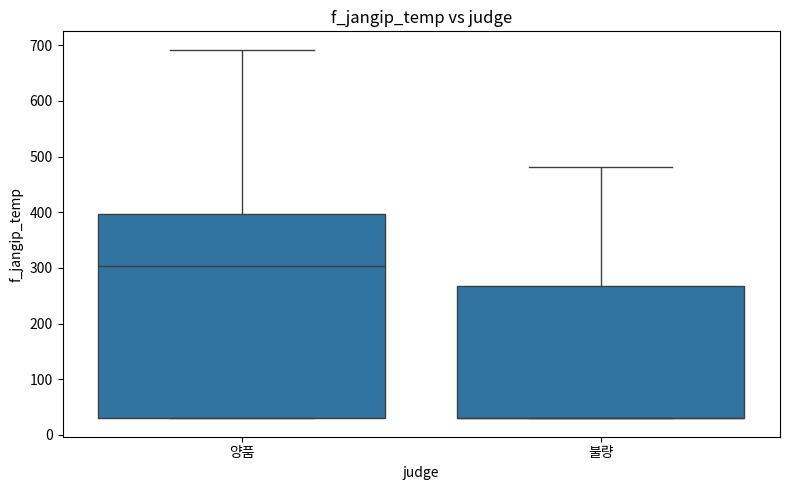

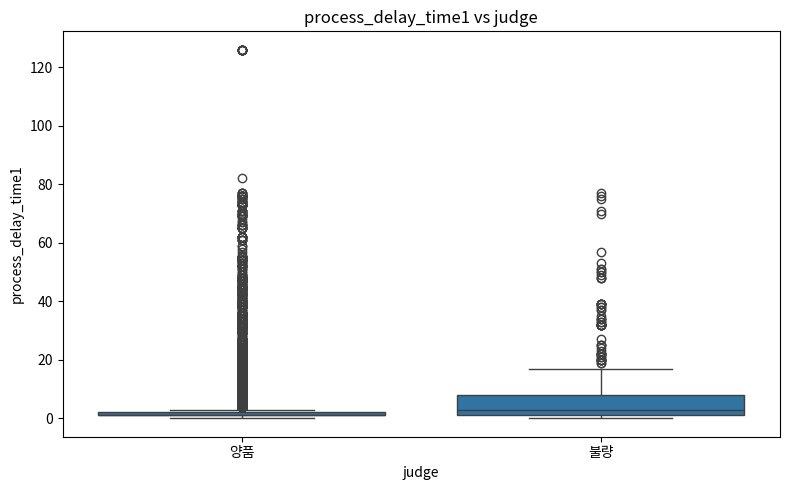

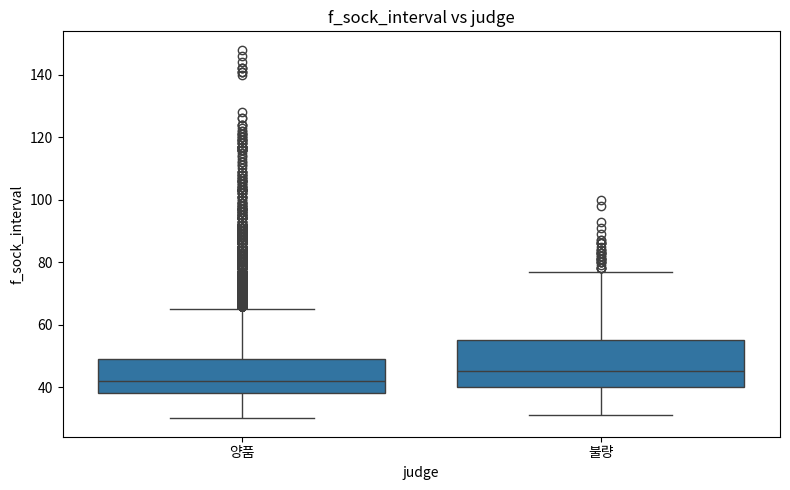

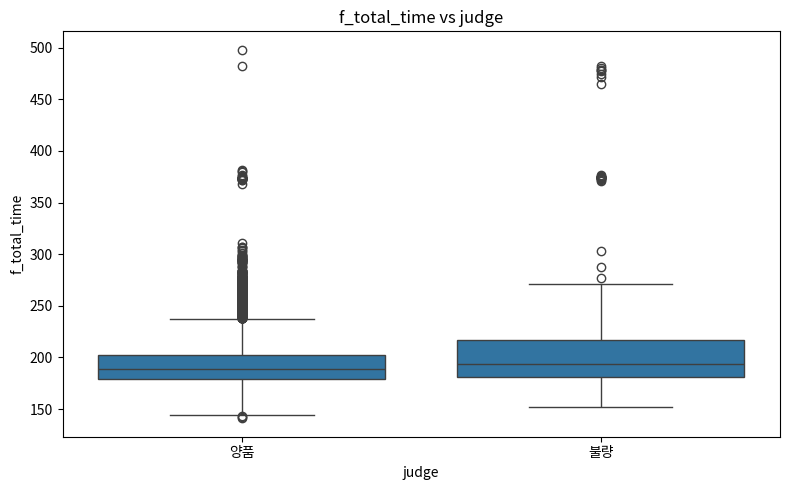

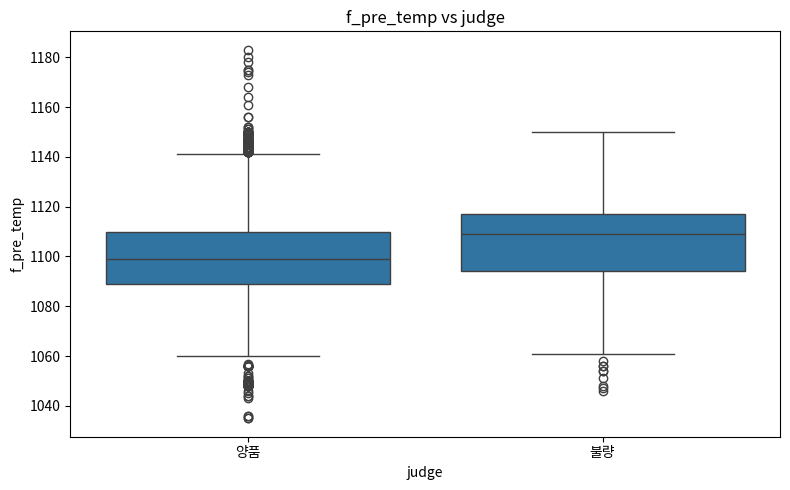

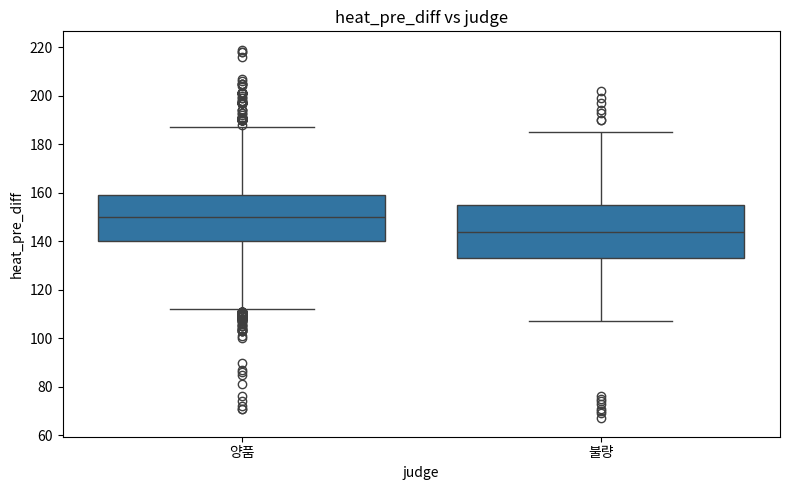

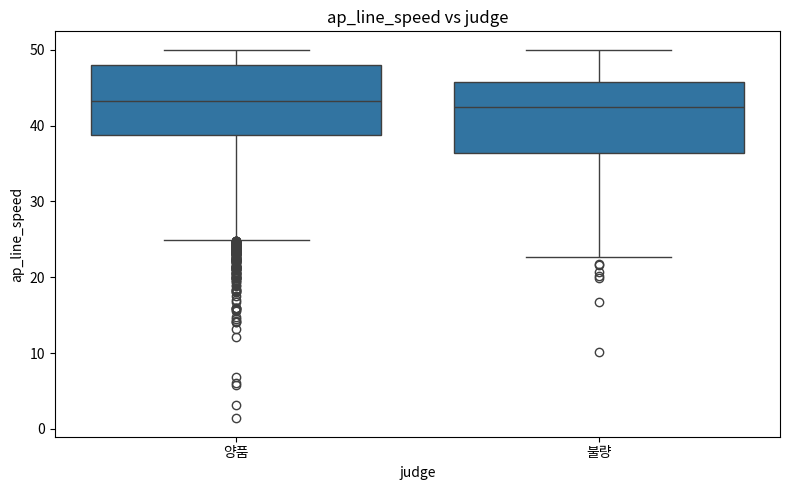

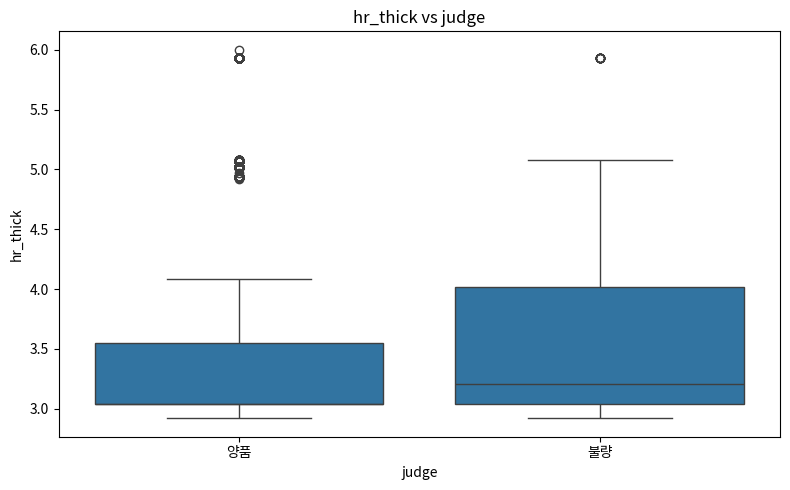

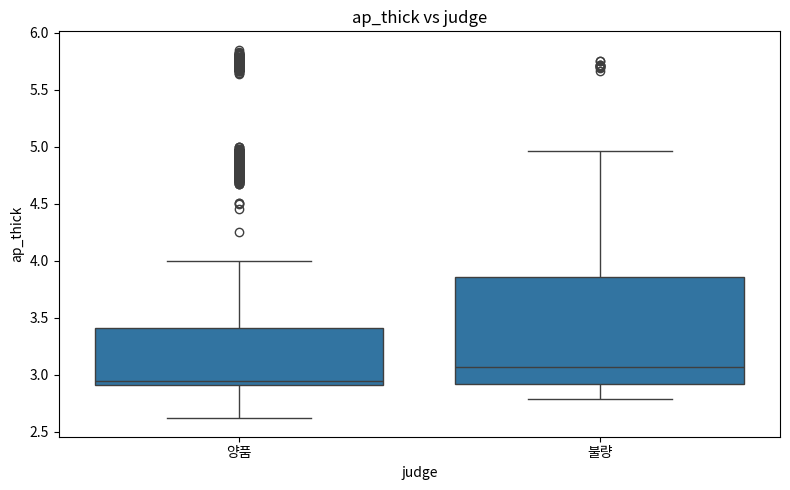

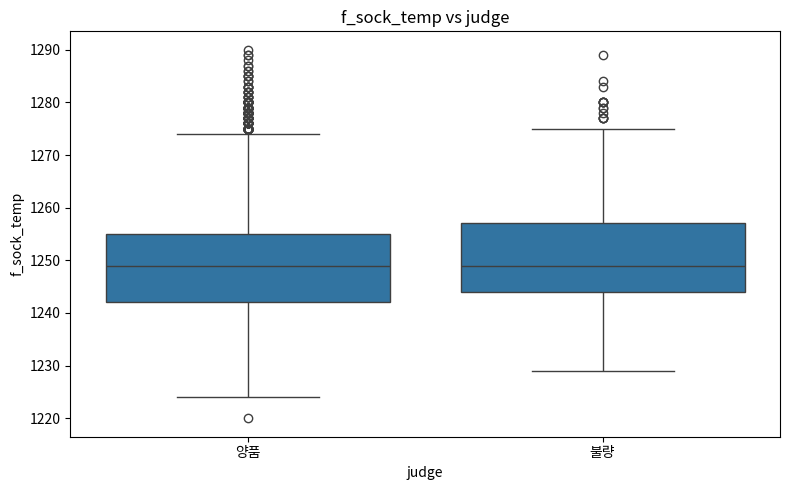

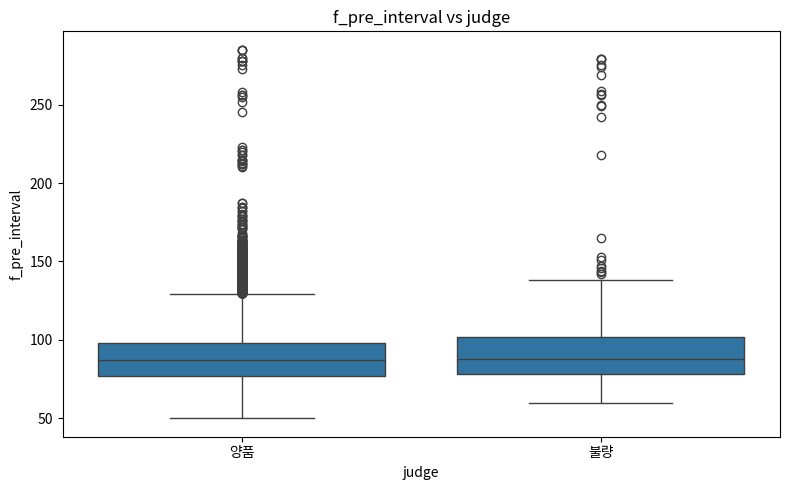

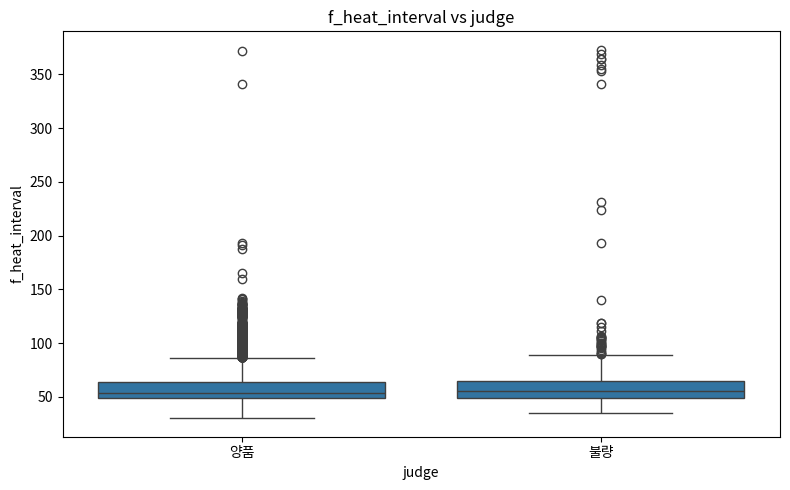

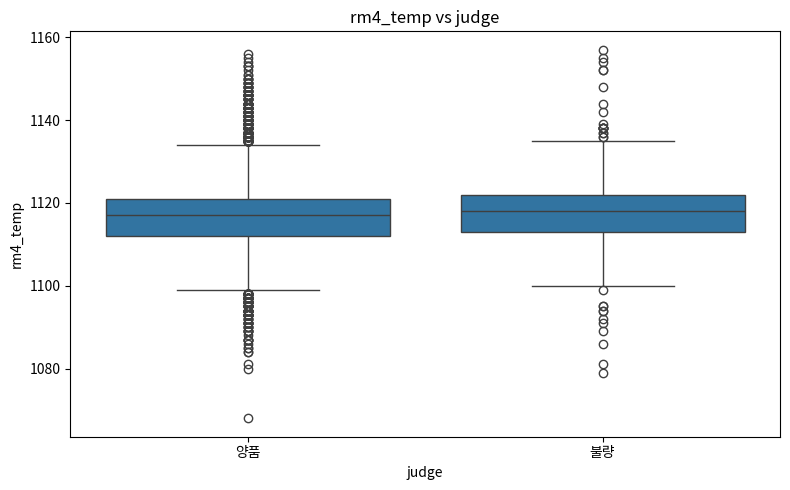

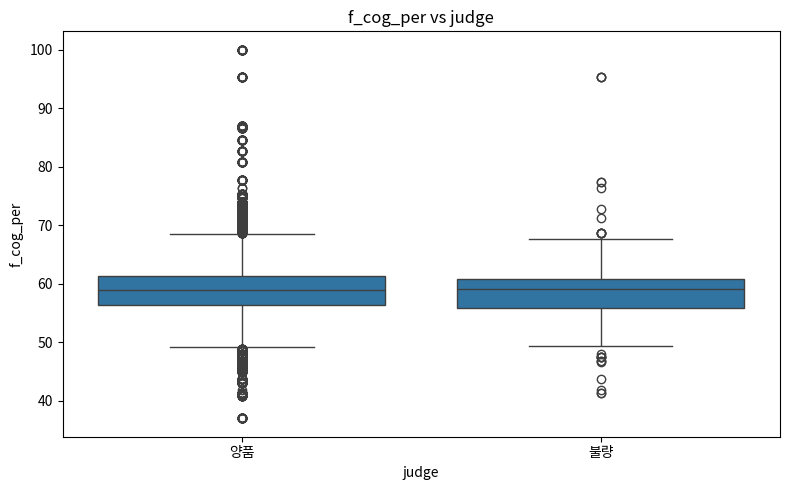

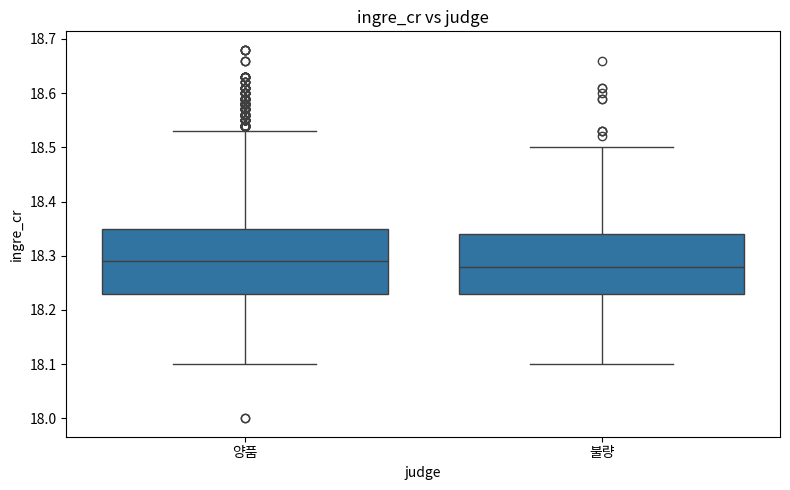

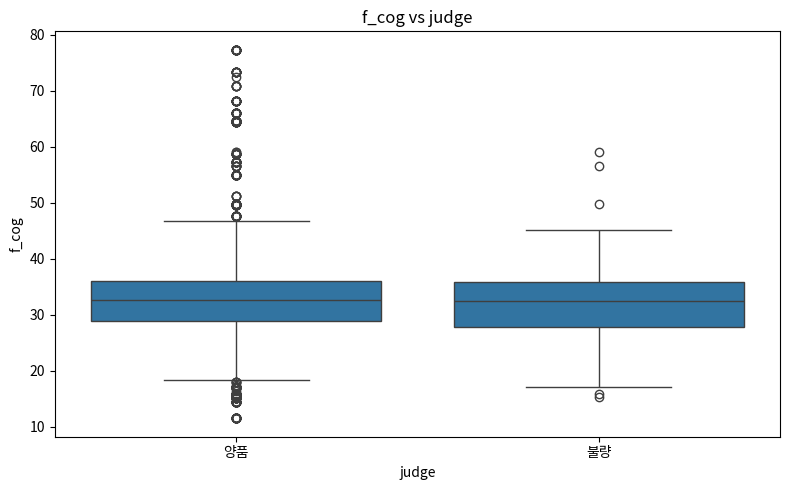

In [ ]:
# 열연공정 1

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['f_jangip_temp','process_delay_time1','f_sock_interval',
            'f_total_time','f_pre_temp','heat_pre_diff',
            'ap_line_speed','hr_thick','ap_thick','f_sock_temp',
            'f_pre_interval','f_heat_interval','rm4_temp',
            'f_cog_per','ingre_cr','f_cog']

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=final_df, x='judge', y=col)
    plt.title(f'{col} vs judge')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 연속형 변수 막대그래프

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# num_cols = [
#    'rm4_temp', 'f_heat_speed',  'f_jangip_temp',
#              'process_delay_time1','f_pre_temp','f_sock_interval',
#              'f_heat_constant','f_total_time','ap_line_speed','ap_thick',
#              'process_delay_time2','f_sock_temp','f_ldg','f_ldg_per','mlac_ratio',
#              'slab_width', 'hr_width'
# ]

# for col in num_cols:
#     plt.figure(figsize=(8, 5))
    
#     # 공통 bin 경계
#     x_min = final_df[col].min()
#     x_max = final_df[col].max()
#     bins = np.linspace(x_min, x_max, 31)

#     # 양품 먼저, 연하게
#     sns.histplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         bins=bins,
#         stat='count',
#         alpha=0.25,
#         label='양품',
#     )

#     # 불량 나중에, 진하게
#     sns.histplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         bins=bins,
#         stat='count',
#         alpha=0.9,
#         label='불량'
#     )

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

## 연속형 KDE

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from IPython.display import display

# # =========================================================
# #1. 기본 설정

# #=========================================================
# #
# target_col = 'judge'
# good_label = '양품'
# bad_label = '불량'

# GOOD_COLOR = '#4C72B0'   # 파란색
# BAD_COLOR  = '#DD4B5A'   # 붉은색

# # 네가 분석할 변수들
# num_cols = [
#     'rm4_temp', 'f_heat_speed',  'f_jangip_temp',
#              'process_delay_time1','f_pre_temp','f_sock_interval',
#              'f_heat_constant','f_total_time','ap_line_speed','ap_thick',
#              'process_delay_time2','f_sock_temp','f_ldg','f_ldg_per','mlac_ratio',
#              'slab_width', 'hr_width'
# ]

# # ---------------------------------------------------------
# # 사용자 기준값 사전
# # 여기에 넣은 변수는 그 값을 기준선으로 사용
# # 없는 변수는 자동으로 중앙값(median) 사용
# # ---------------------------------------------------------
# manual_threshold_dict = {
#     'f_jangip_temp': 200,
#     'rm4_temp': 930,
#     'ap_line_speed': 80,
#     # 필요하면 계속 추가
# }

# # 각 구간 최소 표본 비율
# min_ratio = 0.05

# # 모든 변수 그래프를 다 그리면 너무 많을 수 있으니 True/False로 제어
# show_kde = True
# show_badrate_bar = True
# show_stacked_bar = True

# # =========================================================
# # 2. 함수 정의
# # =========================================================
# def prepare_data(df, x_col, target_col='judge', bad_label='불량'):
#     temp = df[[x_col, target_col]].copy()
#     temp[x_col] = pd.to_numeric(temp[x_col], errors='coerce')
#     temp = temp.dropna(subset=[x_col, target_col]).copy()
#     temp['bad_flag'] = (temp[target_col] == bad_label).astype(int)
#     return temp

# def summarize_by_threshold(data, x_col, threshold):
#     temp = data.copy()
#     temp['구간'] = np.where(temp[x_col] < threshold,
#                           f'{threshold:.2f} 미만',
#                           f'{threshold:.2f} 이상')

#     summary = temp.groupby('구간', observed=False).agg(
#         전체개수=('bad_flag', 'size'),
#         불량개수=('bad_flag', 'sum')
#     ).reset_index()

#     summary['양품개수'] = summary['전체개수'] - summary['불량개수']
#     summary['불량률(%)'] = summary['불량개수'] / summary['전체개수'] * 100
#     summary['양품률(%)'] = summary['양품개수'] / summary['전체개수'] * 100

#     order = [f'{threshold:.2f} 미만', f'{threshold:.2f} 이상']
#     summary['구간'] = pd.Categorical(summary['구간'], categories=order, ordered=True)
#     summary = summary.sort_values('구간').reset_index(drop=True)

#     return summary[['구간', '전체개수', '양품개수', '불량개수', '양품률(%)', '불량률(%)']]

# def find_best_threshold(data, x_col, min_ratio=0.05):
#     x = data[[x_col, 'bad_flag']].dropna().sort_values(x_col).reset_index(drop=True)

#     unique_vals = np.sort(x[x_col].unique())
#     if len(unique_vals) < 2:
#         return None, None

#     candidates = (unique_vals[:-1] + unique_vals[1:]) / 2

#     n = len(x)
#     min_n = max(1, int(n * min_ratio))

#     best_thr = None
#     best_gap = -1
#     best_info = None

#     for thr in candidates:
#         lower = x[x[x_col] < thr]
#         upper = x[x[x_col] >= thr]

#         if len(lower) < min_n or len(upper) < min_n:
#             continue

#         lower_bad_rate = lower['bad_flag'].mean()
#         upper_bad_rate = upper['bad_flag'].mean()
#         gap = abs(upper_bad_rate - lower_bad_rate)

#         if gap > best_gap:
#             best_gap = gap
#             best_thr = thr
#             best_info = {
#                 'threshold': thr,
#                 'lower_n': len(lower),
#                 'upper_n': len(upper),
#                 'lower_bad_rate': lower_bad_rate,
#                 'upper_bad_rate': upper_bad_rate,
#                 'gap': gap
#             }

#     return best_thr, best_info

# def plot_kde_with_thresholds(data, x_col, manual_threshold, best_threshold,
#                              good_label='양품', bad_label='불량'):
#     plt.figure(figsize=(9, 5))

#     sns.kdeplot(
#         data=data[data[target_col] == good_label],
#         x=x_col, fill=True, color=GOOD_COLOR,
#         alpha=0.55, linewidth=1.2, label=good_label
#     )

#     sns.kdeplot(
#         data=data[data[target_col] == bad_label],
#         x=x_col, fill=True, color=BAD_COLOR,
#         alpha=0.40, linewidth=1.2, label=bad_label
#     )

#     ymax = plt.ylim()[1]

#     plt.axvline(x=manual_threshold, color='red', linestyle='--', linewidth=2)
#     plt.text(
#         manual_threshold, ymax * 0.96, f'{manual_threshold:.2f}',
#         color='red', ha='center', va='top', fontsize=11, fontweight='bold'
#     )

#     if best_threshold is not None:
#         plt.axvline(x=best_threshold, color='black', linestyle='--', linewidth=2)
#         plt.text(
#             best_threshold, ymax * 0.88, f'opt={best_threshold:.2f}',
#             color='black', ha='center', va='top', fontsize=10, fontweight='bold'
#         )

#     plt.title(f'{x_col} by judge')
#     plt.xlabel(x_col)
#     plt.ylabel('Density')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# def plot_badrate_bar(summary, title):
#     plt.figure(figsize=(6, 4))
#     plt.bar(summary['구간'], summary['불량률(%)'], color=BAD_COLOR, edgecolor='black')
#     plt.title(title)
#     plt.ylabel('불량률 (%)')
#     for i, v in enumerate(summary['불량률(%)']):
#         plt.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=10)
#     plt.tight_layout()
#     plt.show()

# def plot_stacked_bar(summary, title):
#     plt.figure(figsize=(6, 4))
#     plt.bar(summary['구간'], summary['양품개수'],
#             color=GOOD_COLOR, edgecolor='black', label='양품')
#     plt.bar(summary['구간'], summary['불량개수'],
#             bottom=summary['양품개수'],
#             color=BAD_COLOR, edgecolor='black', label='불량')
#     plt.title(title)
#     plt.ylabel('개수')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# # =========================================================
# # 3. 전체 변수 일괄 실행
# # =========================================================
# all_compare_rows = []
# all_best_rows = []

# for x_col in num_cols:
#     print('=' * 90)
#     print(f'[변수] {x_col}')

#     try:
#         df_var = prepare_data(final_df, x_col, target_col=target_col, bad_label=bad_label)

#         if len(df_var) == 0:
#             print('유효 데이터가 없어 건너뜀')
#             continue

#         # 사용자 기준값: dict에 있으면 그 값, 없으면 중앙값
#         manual_threshold = manual_threshold_dict.get(x_col, df_var[x_col].median())

#         # 자동 최적 기준값
#         best_threshold, best_info = find_best_threshold(df_var, x_col, min_ratio=min_ratio)

#         # 요약표
#         manual_summary = summarize_by_threshold(df_var, x_col, manual_threshold)

#         if best_threshold is not None:
#             auto_summary = summarize_by_threshold(df_var, x_col, best_threshold)
#         else:
#             auto_summary = None

#         print(f'[사용자 기준값] {manual_threshold:.2f}')
#         display(manual_summary.round(2))

#         if best_threshold is not None:
#             print(f'[자동 최적 기준값] {best_threshold:.2f}')
#             print(f"구간별 불량률 차이 = {best_info['gap']*100:.2f}%p")
#             display(auto_summary.round(2))
#         else:
#             print('자동 최적 기준값을 찾지 못함')

#         # 비교표
#         compare_list = [
#             manual_summary.assign(기준종류=f'사용자기준({manual_threshold:.2f})', 변수=x_col)
#         ]

#         if auto_summary is not None:
#             compare_list.append(
#                 auto_summary.assign(기준종류=f'자동최적({best_threshold:.2f})', 변수=x_col)
#             )

#         compare_df = pd.concat(compare_list, ignore_index=True)
#         compare_df = compare_df[['변수', '기준종류', '구간', '전체개수', '양품개수', '불량개수', '양품률(%)', '불량률(%)']]

#         print('[기준값 비교표]')
#         display(compare_df.round(2))

#         all_compare_rows.append(compare_df)

#         # 최적값 요약 저장
#         manual_gap = abs(manual_summary.loc[0, '불량률(%)'] - manual_summary.loc[1, '불량률(%)']) \
#             if len(manual_summary) == 2 else np.nan

#         all_best_rows.append({
#             '변수': x_col,
#             '사용자기준값': round(manual_threshold, 4),
#             '사용자기준_불량률차이(%p)': round(manual_gap, 4) if pd.notna(manual_gap) else np.nan,
#             '자동최적값': round(best_threshold, 4) if best_threshold is not None else np.nan,
#             '자동최적_불량률차이(%p)': round(best_info['gap'] * 100, 4) if best_info is not None else np.nan,
#             '자동최적_미만불량률(%)': round(best_info['lower_bad_rate'] * 100, 4) if best_info is not None else np.nan,
#             '자동최적_이상불량률(%)': round(best_info['upper_bad_rate'] * 100, 4) if best_info is not None else np.nan
#         })

#         # 그래프
#         if show_kde:
#             plot_kde_with_thresholds(
#                 df_var, x_col, manual_threshold, best_threshold,
#                 good_label=good_label, bad_label=bad_label
#             )

#         if show_badrate_bar:
#             plot_badrate_bar(
#                 manual_summary,
#                 f'{x_col} - 사용자 기준 {manual_threshold:.2f}'
#             )
#             if auto_summary is not None:
#                 plot_badrate_bar(
#                     auto_summary,
#                     f'{x_col} - 자동 최적 기준 {best_threshold:.2f}'
#                 )

#         if show_stacked_bar:
#             plot_stacked_bar(
#                 manual_summary,
#                 f'{x_col} - 사용자 기준 {manual_threshold:.2f}'
#             )
#             if auto_summary is not None:
#                 plot_stacked_bar(
#                     auto_summary,
#                     f'{x_col} - 자동 최적 기준 {best_threshold:.2f}'
#                 )

#     except Exception as e:
#         print(f'에러 발생: {x_col} -> {e}')

# # =========================================================
# # 4. 전체 변수 최적값 요약표
# # =========================================================
# best_summary_df = pd.DataFrame(all_best_rows)
# compare_all_df = pd.concat(all_compare_rows, ignore_index=True) if all_compare_rows else pd.DataFrame()

# print('=' * 90)
# print('[전체 변수 자동 최적값 요약표]')
# display(best_summary_df)

# print('[전체 변수 기준값 비교표 전체]')
# display(compare_all_df.round(2))

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# num_cols = [
#         'rm4_temp', 'f_heat_speed',  'f_jangip_temp',
#              'process_delay_time1','f_pre_temp','f_sock_interval',
#              'f_heat_constant','f_total_time','ap_line_speed','ap_thick',
#              'process_delay_time2','f_sock_temp','f_ldg','f_ldg_per','mlac_ratio',
#              'slab_width', 'hr_width'
# ]

# for col in num_cols:
#     plt.figure(figsize=(8, 5))

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         # color='royalblue',
#         label='양품'
#     )

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         # color='crimson',
#         label='불량'
#     )

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from scipy.stats import gaussian_kde

# num_cols = [
#     'f_heat_total', 'f_heat_speed', 'f_total_time',
#     'f_heat_constant', 'f_weighted_avg_temp',
#     'f_heat_input_per_area', 'process_delay_time1','composition_score','process_delay_time2'
# ]

# for col in num_cols:
#     good = final_df.loc[final_df['judge'] == '양품', col].dropna()
#     bad = final_df.loc[final_df['judge'] == '불량', col].dropna()


#     # 데이터가 너무 적거나 값이 거의 하나면 KDE 불가
#     if len(good) < 2 or len(bad) < 2 or good.nunique() < 2 or bad.nunique() < 2:
#         print(f'{col}: KDE 계산 불가')
#         continue

#     plt.figure(figsize=(8, 5))

#     # 기존 KDE 그래프
#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         # color='royalblue',
#         label='양품'
#     )

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         # color='crimson',
#         label='불량'
#     )

#     # 공통 x grid 생성
#     x_min = min(good.min(), bad.min())
#     x_max = max(good.max(), bad.max())
#     x_grid = np.linspace(x_min, x_max, 500)

#     # KDE 직접 계산
#     good_kde = gaussian_kde(good)
#     bad_kde = gaussian_kde(bad)

#     y_good = good_kde(x_grid)
#     y_bad = bad_kde(x_grid)

#     # 불량 KDE가 더 큰 구간 찾기
#     mask = y_bad > y_good

#     # 연속 구간 start/end 찾기
#     diff = np.diff(mask.astype(int))
#     starts = np.where(diff == 1)[0] + 1
#     ends = np.where(diff == -1)[0] + 1

#     if mask[0]:
#         starts = np.insert(starts, 0, 0)
#     if mask[-1]:
#         ends = np.append(ends, len(mask) - 1)

#     # 각 구간에 점선 및 x값 표시
#     y_max = max(y_good.max(), y_bad.max())

#     for s, e in zip(starts, ends):
#         x_start = x_grid[s]
#         x_end = x_grid[e]

#         # 시작/끝 점선
#         plt.axvline(x=x_start, color='red', linestyle='--', linewidth=1.5)
#         plt.axvline(x=x_end, color='red', linestyle='--', linewidth=1.5)

#         # 텍스트 표시
#         plt.text(x_start, y_max * 0.95, f'{x_start:.2f}', color='red',
#                  rotation=90, va='top', ha='right', fontsize=8)
#         plt.text(x_end, y_max * 0.95, f'{x_end:.2f}', color='red',
#                  rotation=90, va='top', ha='left', fontsize=8)

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # 콘솔에도 구간 출력
#     if len(starts) > 0:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간')
#         for s, e in zip(starts, ends):
#             print(f' - {x_grid[s]:.4f} ~ {x_grid[e]:.4f}')
#     else:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간 없음')

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from scipy.stats import gaussian_kde

# num_cols = [
#     'f_heat_total', 'f_heat_speed', 'f_total_time',
#     'f_heat_constant', 'f_weighted_avg_temp',
#     'f_heat_input_per_area', 'process_delay_time1','composition_score','process_delay_time2'
# ]

# for col in num_cols:
#     good = final_df.loc[final_df['judge'] == '양품', col].dropna()
#     bad = final_df.loc[final_df['judge'] == '불량', col].dropna()


#     # 데이터가 너무 적거나 값이 거의 하나면 KDE 불가
#     if len(good) < 2 or len(bad) < 2 or good.nunique() < 2 or bad.nunique() < 2:
#         print(f'{col}: KDE 계산 불가')
#         continue

#     plt.figure(figsize=(8, 5))

#     # 기존 KDE 그래프
#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         color='royalblue',
#         label='양품'
#     )

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         color='crimson',
#         label='불량'
#     )

#     # 공통 x grid 생성
#     x_min = min(good.min(), bad.min())
#     x_max = max(good.max(), bad.max())
#     x_grid = np.linspace(x_min, x_max, 500)

#     # KDE 직접 계산
#     good_kde = gaussian_kde(good)
#     bad_kde = gaussian_kde(bad)

#     y_good = good_kde(x_grid)
#     y_bad = bad_kde(x_grid)

#     # 불량 KDE가 더 큰 구간 찾기
#     mask = y_bad > y_good

#     # 연속 구간 start/end 찾기
#     diff = np.diff(mask.astype(int))
#     starts = np.where(diff == 1)[0] + 1
#     ends = np.where(diff == -1)[0] + 1

#     if mask[0]:
#         starts = np.insert(starts, 0, 0)
#     if mask[-1]:
#         ends = np.append(ends, len(mask) - 1)

#     # 각 구간에 점선 및 x값 표시
#     y_max = max(y_good.max(), y_bad.max())

#     for s, e in zip(starts, ends):
#         x_start = x_grid[s]
#         x_end = x_grid[e]

#         # 시작/끝 점선
#         plt.axvline(x=x_start, color='red', linestyle='--', linewidth=1.5)
#         plt.axvline(x=x_end, color='red', linestyle='--', linewidth=1.5)

#         # 텍스트 표시
#         plt.text(x_start, y_max * 0.95, f'{x_start:.2f}', color='red',
#                  rotation=90, va='top', ha='right', fontsize=8)
#         plt.text(x_end, y_max * 0.95, f'{x_end:.2f}', color='red',
#                  rotation=90, va='top', ha='left', fontsize=8)

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # 콘솔에도 구간 출력
#     if len(starts) > 0:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간')
#         for s, e in zip(starts, ends):
#             print(f' - {x_grid[s]:.4f} ~ {x_grid[e]:.4f}')
#     else:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간 없음')

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from scipy.stats import gaussian_kde

# num_cols = [
#     'f_heat_total', 'f_heat_speed', 'f_total_time',
#     'f_heat_constant', 'f_weighted_avg_temp',
#     'f_heat_input_per_area', 'process_delay_time1','composition_score','process_delay_time2'
# ]

# for col in num_cols:
#     good = final_df.loc[final_df['judge'] == '양품', col].dropna()
#     bad = final_df.loc[final_df['judge'] == '불량', col].dropna()


#     # 데이터가 너무 적거나 값이 거의 하나면 KDE 불가
#     if len(good) < 2 or len(bad) < 2 or good.nunique() < 2 or bad.nunique() < 2:
#         print(f'{col}: KDE 계산 불가')
#         continue

#     plt.figure(figsize=(8, 5))

#     # 기존 KDE 그래프
#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         color='royalblue',
#         label='양품'
#     )

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         color='crimson',
#         label='불량'
#     )

#     # 공통 x grid 생성
#     x_min = min(good.min(), bad.min())
#     x_max = max(good.max(), bad.max())
#     x_grid = np.linspace(x_min, x_max, 500)

#     # KDE 직접 계산
#     good_kde = gaussian_kde(good)
#     bad_kde = gaussian_kde(bad)

#     y_good = good_kde(x_grid)
#     y_bad = bad_kde(x_grid)

#     # 불량 KDE가 더 큰 구간 찾기
#     mask = y_bad > y_good

#     # 연속 구간 start/end 찾기
#     diff = np.diff(mask.astype(int))
#     starts = np.where(diff == 1)[0] + 1
#     ends = np.where(diff == -1)[0] + 1

#     if mask[0]:
#         starts = np.insert(starts, 0, 0)
#     if mask[-1]:
#         ends = np.append(ends, len(mask) - 1)

#     # 각 구간에 점선 및 x값 표시
#     y_max = max(y_good.max(), y_bad.max())

#     for s, e in zip(starts, ends):
#         x_start = x_grid[s]
#         x_end = x_grid[e]

#         # 시작/끝 점선
#         plt.axvline(x=x_start, color='red', linestyle='--', linewidth=1.5)
#         plt.axvline(x=x_end, color='red', linestyle='--', linewidth=1.5)

#         # 텍스트 표시
#         plt.text(x_start, y_max * 0.95, f'{x_start:.2f}', color='red',
#                  rotation=90, va='top', ha='right', fontsize=8)
#         plt.text(x_end, y_max * 0.95, f'{x_end:.2f}', color='red',
#                  rotation=90, va='top', ha='left', fontsize=8)

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # 콘솔에도 구간 출력
#     if len(starts) > 0:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간')
#         for s, e in zip(starts, ends):
#             print(f' - {x_grid[s]:.4f} ~ {x_grid[e]:.4f}')
#     else:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간 없음')

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# target_ranges = {
#     'composition_score': [
#         (6.0310, 6.2019, 10),
#         (6.2408, 6.3920, 10)
#     ],
#     'process_delay## 열연공정 1
sns.boxplot(data=final_df, hue = 'ap_plant', y = 'ap_line_speed')
# sns.countplot(data=final_df, hue='furnace_no', x='judge')
# cat_cols = ['furnace_no', 'f_jangip_gubun','hr_thick_group']

# plt.figure(figsize=(12, 5))

# for i, col in enumerate(cat_cols, 1):
#     plt.subplot(1, 3, i)
#     sns.countplot(data=final_df, x=col, hue='judge')
#     plt.title(f'{col} by judge')
#     plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()
# sns.countplot(data=final_df, x = 'f_jangip_gubun')
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# cat_cols = ['furnace_no', 'f_jangip_gubun', 'hr_thick_group']

# # 불량 데이터만 추출
# bad_df = final_df[final_df['judge'] == '불량'].copy()

# for col in cat_cols:
#     count_df = (
#         bad_df[col]
#         .value_counts(dropna=False)
#         .reset_index()
#     )
#     count_df.columns = [col, 'bad_count']

#     # furnace_no만 호기 순서대로 정렬
#     if col == 'furnace_no':
#         furnace_order = ['1호기', '2호기', '3호기', '4호기']
#         count_df[col] = pd.Categorical(count_df[col], categories=furnace_order, ordered=True)
#         count_df = count_df.sort_values(col)

#     plt.figure(figsize=(8, 5))
#     ax = sns.barplot(data=count_df, x=col, y='bad_count',hue = col)

#     for i, v in enumerate(count_df['bad_count']):
#         ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

#     plt.title(f'{col}별 불량 개수')
#     plt.ylabel('Bad Count')
#     plt.xlabel(col)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

#     print(f'\n[{col}]')
#     print(count_df)
#     print('총 불량 개수:', count_df['bad_count'].sum())
## 연속형변수 boxplot
# 유의 연속형 변수 박스플랏
num_cols = ['f_jangip_temp','process_delay_time1','f_sock_interval',
            'f_total_time','f_pre_temp','heat_pre_diff',
            'ap_line_speed','hr_thick','ap_thick','f_sock_temp',
            'f_pre_interval','f_heat_interval','rm4_temp',
            'f_cog_per','ingre_cr','f_cog']

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=final_df, x='judge', y=col, hue = 'judge')
    plt.title(f'{col} vs judge')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
# 열연공정 1

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['f_jangip_temp','process_delay_time1','f_sock_interval',
            'f_total_time','f_pre_temp','heat_pre_diff',
            'ap_line_speed','hr_thick','ap_thick','f_sock_temp',
            'f_pre_interval','f_heat_interval','rm4_temp',
            'f_cog_per','ingre_cr','f_cog']

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=final_df, x='judge', y=col)
    plt.title(f'{col} vs judge')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
## 연속형 변수 막대그래프
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# num_cols = [
#    'rm4_temp', 'f_heat_speed',  'f_jangip_temp',
#              'process_delay_time1','f_pre_temp','f_sock_interval',
#              'f_heat_constant','f_total_time','ap_line_speed','ap_thick',
#              'process_delay_time2','f_sock_temp','f_ldg','f_ldg_per','mlac_ratio',
#              'slab_width', 'hr_width'
# ]

# for col in num_cols:
#     plt.figure(figsize=(8, 5))
    
#     # 공통 bin 경계
#     x_min = final_df[col].min()
#     x_max = final_df[col].max()
#     bins = np.linspace(x_min, x_max, 31)

#     # 양품 먼저, 연하게
#     sns.histplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         bins=bins,
#         stat='count',
#         alpha=0.25,
#         label='양품',
#     )

#     # 불량 나중에, 진하게
#     sns.histplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         bins=bins,
#         stat='count',
#         alpha=0.9,
#         label='불량'
#     )

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()
## 연속형 KDE
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from IPython.display import display

# # =========================================================
# #1. 기본 설정

# #=========================================================
# #
# target_col = 'judge'
# good_label = '양품'
# bad_label = '불량'

# GOOD_COLOR = '#4C72B0'   # 파란색
# BAD_COLOR  = '#DD4B5A'   # 붉은색

# # 네가 분석할 변수들
# num_cols = [
#     'rm4_temp', 'f_heat_speed',  'f_jangip_temp',
#              'process_delay_time1','f_pre_temp','f_sock_interval',
#              'f_heat_constant','f_total_time','ap_line_speed','ap_thick',
#              'process_delay_time2','f_sock_temp','f_ldg','f_ldg_per','mlac_ratio',
#              'slab_width', 'hr_width'
# ]

# # ---------------------------------------------------------
# # 사용자 기준값 사전
# # 여기에 넣은 변수는 그 값을 기준선으로 사용
# # 없는 변수는 자동으로 중앙값(median) 사용
# # ---------------------------------------------------------
# manual_threshold_dict = {
#     'f_jangip_temp': 200,
#     'rm4_temp': 930,
#     'ap_line_speed': 80,
#     # 필요하면 계속 추가
# }

# # 각 구간 최소 표본 비율
# min_ratio = 0.05

# # 모든 변수 그래프를 다 그리면 너무 많을 수 있으니 True/False로 제어
# show_kde = True
# show_badrate_bar = True
# show_stacked_bar = True

# # =========================================================
# # 2. 함수 정의
# # =========================================================
# def prepare_data(df, x_col, target_col='judge', bad_label='불량'):
#     temp = df[[x_col, target_col]].copy()
#     temp[x_col] = pd.to_numeric(temp[x_col], errors='coerce')
#     temp = temp.dropna(subset=[x_col, target_col]).copy()
#     temp['bad_flag'] = (temp[target_col] == bad_label).astype(int)
#     return temp

# def summarize_by_threshold(data, x_col, threshold):
#     temp = data.copy()
#     temp['구간'] = np.where(temp[x_col] < threshold,
#                           f'{threshold:.2f} 미만',
#                           f'{threshold:.2f} 이상')

#     summary = temp.groupby('구간', observed=False).agg(
#         전체개수=('bad_flag', 'size'),
#         불량개수=('bad_flag', 'sum')
#     ).reset_index()

#     summary['양품개수'] = summary['전체개수'] - summary['불량개수']
#     summary['불량률(%)'] = summary['불량개수'] / summary['전체개수'] * 100
#     summary['양품률(%)'] = summary['양품개수'] / summary['전체개수'] * 100

#     order = [f'{threshold:.2f} 미만', f'{threshold:.2f} 이상']
#     summary['구간'] = pd.Categorical(summary['구간'], categories=order, ordered=True)
#     summary = summary.sort_values('구간').reset_index(drop=True)

#     return summary[['구간', '전체개수', '양품개수', '불량개수', '양품률(%)', '불량률(%)']]

# def find_best_threshold(data, x_col, min_ratio=0.05):
#     x = data[[x_col, 'bad_flag']].dropna().sort_values(x_col).reset_index(drop=True)

#     unique_vals = np.sort(x[x_col].unique())
#     if len(unique_vals) < 2:
#         return None, None

#     candidates = (unique_vals[:-1] + unique_vals[1:]) / 2

#     n = len(x)
#     min_n = max(1, int(n * min_ratio))

#     best_thr = None
#     best_gap = -1
#     best_info = None

#     for thr in candidates:
#         lower = x[x[x_col] < thr]
#         upper = x[x[x_col] >= thr]

#         if len(lower) < min_n or len(upper) < min_n:
#             continue

#         lower_bad_rate = lower['bad_flag'].mean()
#         upper_bad_rate = upper['bad_flag'].mean()
#         gap = abs(upper_bad_rate - lower_bad_rate)

#         if gap > best_gap:
#             best_gap = gap
#             best_thr = thr
#             best_info = {
#                 'threshold': thr,
#                 'lower_n': len(lower),
#                 'upper_n': len(upper),
#                 'lower_bad_rate': lower_bad_rate,
#                 'upper_bad_rate': upper_bad_rate,
#                 'gap': gap
#             }

#     return best_thr, best_info

# def plot_kde_with_thresholds(data, x_col, manual_threshold, best_threshold,
#                              good_label='양품', bad_label='불량'):
#     plt.figure(figsize=(9, 5))

#     sns.kdeplot(
#         data=data[data[target_col] == good_label],
#         x=x_col, fill=True, color=GOOD_COLOR,
#         alpha=0.55, linewidth=1.2, label=good_label
#     )

#     sns.kdeplot(
#         data=data[data[target_col] == bad_label],
#         x=x_col, fill=True, color=BAD_COLOR,
#         alpha=0.40, linewidth=1.2, label=bad_label
#     )

#     ymax = plt.ylim()[1]

#     plt.axvline(x=manual_threshold, color='red', linestyle='--', linewidth=2)
#     plt.text(
#         manual_threshold, ymax * 0.96, f'{manual_threshold:.2f}',
#         color='red', ha='center', va='top', fontsize=11, fontweight='bold'
#     )

#     if best_threshold is not None:
#         plt.axvline(x=best_threshold, color='black', linestyle='--', linewidth=2)
#         plt.text(
#             best_threshold, ymax * 0.88, f'opt={best_threshold:.2f}',
#             color='black', ha='center', va='top', fontsize=10, fontweight='bold'
#         )

#     plt.title(f'{x_col} by judge')
#     plt.xlabel(x_col)
#     plt.ylabel('Density')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# def plot_badrate_bar(summary, title):
#     plt.figure(figsize=(6, 4))
#     plt.bar(summary['구간'], summary['불량률(%)'], color=BAD_COLOR, edgecolor='black')
#     plt.title(title)
#     plt.ylabel('불량률 (%)')
#     for i, v in enumerate(summary['불량률(%)']):
#         plt.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=10)
#     plt.tight_layout()
#     plt.show()

# def plot_stacked_bar(summary, title):
#     plt.figure(figsize=(6, 4))
#     plt.bar(summary['구간'], summary['양품개수'],
#             color=GOOD_COLOR, edgecolor='black', label='양품')
#     plt.bar(summary['구간'], summary['불량개수'],
#             bottom=summary['양품개수'],
#             color=BAD_COLOR, edgecolor='black', label='불량')
#     plt.title(title)
#     plt.ylabel('개수')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# # =========================================================
# # 3. 전체 변수 일괄 실행
# # =========================================================
# all_compare_rows = []
# all_best_rows = []

# for x_col in num_cols:
#     print('=' * 90)
#     print(f'[변수] {x_col}')

#     try:
#         df_var = prepare_data(final_df, x_col, target_col=target_col, bad_label=bad_label)

#         if len(df_var) == 0:
#             print('유효 데이터가 없어 건너뜀')
#             continue

#         # 사용자 기준값: dict에 있으면 그 값, 없으면 중앙값
#         manual_threshold = manual_threshold_dict.get(x_col, df_var[x_col].median())

#         # 자동 최적 기준값
#         best_threshold, best_info = find_best_threshold(df_var, x_col, min_ratio=min_ratio)

#         # 요약표
#         manual_summary = summarize_by_threshold(df_var, x_col, manual_threshold)

#         if best_threshold is not None:
#             auto_summary = summarize_by_threshold(df_var, x_col, best_threshold)
#         else:
#             auto_summary = None

#         print(f'[사용자 기준값] {manual_threshold:.2f}')
#         display(manual_summary.round(2))

#         if best_threshold is not None:
#             print(f'[자동 최적 기준값] {best_threshold:.2f}')
#             print(f"구간별 불량률 차이 = {best_info['gap']*100:.2f}%p")
#             display(auto_summary.round(2))
#         else:
#             print('자동 최적 기준값을 찾지 못함')

#         # 비교표
#         compare_list = [
#             manual_summary.assign(기준종류=f'사용자기준({manual_threshold:.2f})', 변수=x_col)
#         ]

#         if auto_summary is not None:
#             compare_list.append(
#                 auto_summary.assign(기준종류=f'자동최적({best_threshold:.2f})', 변수=x_col)
#             )

#         compare_df = pd.concat(compare_list, ignore_index=True)
#         compare_df = compare_df[['변수', '기준종류', '구간', '전체개수', '양품개수', '불량개수', '양품률(%)', '불량률(%)']]

#         print('[기준값 비교표]')
#         display(compare_df.round(2))

#         all_compare_rows.append(compare_df)

#         # 최적값 요약 저장
#         manual_gap = abs(manual_summary.loc[0, '불량률(%)'] - manual_summary.loc[1, '불량률(%)']) \
#             if len(manual_summary) == 2 else np.nan

#         all_best_rows.append({
#             '변수': x_col,
#             '사용자기준값': round(manual_threshold, 4),
#             '사용자기준_불량률차이(%p)': round(manual_gap, 4) if pd.notna(manual_gap) else np.nan,
#             '자동최적값': round(best_threshold, 4) if best_threshold is not None else np.nan,
#             '자동최적_불량률차이(%p)': round(best_info['gap'] * 100, 4) if best_info is not None else np.nan,
#             '자동최적_미만불량률(%)': round(best_info['lower_bad_rate'] * 100, 4) if best_info is not None else np.nan,
#             '자동최적_이상불량률(%)': round(best_info['upper_bad_rate'] * 100, 4) if best_info is not None else np.nan
#         })

#         # 그래프
#         if show_kde:
#             plot_kde_with_thresholds(
#                 df_var, x_col, manual_threshold, best_threshold,
#                 good_label=good_label, bad_label=bad_label
#             )

#         if show_badrate_bar:
#             plot_badrate_bar(
#                 manual_summary,
#                 f'{x_col} - 사용자 기준 {manual_threshold:.2f}'
#             )
#             if auto_summary is not None:
#                 plot_badrate_bar(
#                     auto_summary,
#                     f'{x_col} - 자동 최적 기준 {best_threshold:.2f}'
#                 )

#         if show_stacked_bar:
#             plot_stacked_bar(
#                 manual_summary,
#                 f'{x_col} - 사용자 기준 {manual_threshold:.2f}'
#             )
#             if auto_summary is not None:
#                 plot_stacked_bar(
#                     auto_summary,
#                     f'{x_col} - 자동 최적 기준 {best_threshold:.2f}'
#                 )

#     except Exception as e:
#         print(f'에러 발생: {x_col} -> {e}')

# # =========================================================
# # 4. 전체 변수 최적값 요약표
# # =========================================================
# best_summary_df = pd.DataFrame(all_best_rows)
# compare_all_df = pd.concat(all_compare_rows, ignore_index=True) if all_compare_rows else pd.DataFrame()

# print('=' * 90)
# print('[전체 변수 자동 최적값 요약표]')
# display(best_summary_df)

# print('[전체 변수 기준값 비교표 전체]')
# display(compare_all_df.round(2))
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# num_cols = [
#         'rm4_temp', 'f_heat_speed',  'f_jangip_temp',
#              'process_delay_time1','f_pre_temp','f_sock_interval',
#              'f_heat_constant','f_total_time','ap_line_speed','ap_thick',
#              'process_delay_time2','f_sock_temp','f_ldg','f_ldg_per','mlac_ratio',
#              'slab_width', 'hr_width'
# ]

# for col in num_cols:
#     plt.figure(figsize=(8, 5))

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         # color='royalblue',
#         label='양품'
#     )

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         # color='crimson',
#         label='불량'
#     )

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from scipy.stats import gaussian_kde

# num_cols = [
#     'f_heat_total', 'f_heat_speed', 'f_total_time',
#     'f_heat_constant', 'f_weighted_avg_temp',
#     'f_heat_input_per_area', 'process_delay_time1','composition_score','process_delay_time2'
# ]

# for col in num_cols:
#     good = final_df.loc[final_df['judge'] == '양품', col].dropna()
#     bad = final_df.loc[final_df['judge'] == '불량', col].dropna()


#     # 데이터가 너무 적거나 값이 거의 하나면 KDE 불가
#     if len(good) < 2 or len(bad) < 2 or good.nunique() < 2 or bad.nunique() < 2:
#         print(f'{col}: KDE 계산 불가')
#         continue

#     plt.figure(figsize=(8, 5))

#     # 기존 KDE 그래프
#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         # color='royalblue',
#         label='양품'
#     )

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         # color='crimson',
#         label='불량'
#     )

#     # 공통 x grid 생성
#     x_min = min(good.min(), bad.min())
#     x_max = max(good.max(), bad.max())
#     x_grid = np.linspace(x_min, x_max, 500)

#     # KDE 직접 계산
#     good_kde = gaussian_kde(good)
#     bad_kde = gaussian_kde(bad)

#     y_good = good_kde(x_grid)
#     y_bad = bad_kde(x_grid)

#     # 불량 KDE가 더 큰 구간 찾기
#     mask = y_bad > y_good

#     # 연속 구간 start/end 찾기
#     diff = np.diff(mask.astype(int))
#     starts = np.where(diff == 1)[0] + 1
#     ends = np.where(diff == -1)[0] + 1

#     if mask[0]:
#         starts = np.insert(starts, 0, 0)
#     if mask[-1]:
#         ends = np.append(ends, len(mask) - 1)

#     # 각 구간에 점선 및 x값 표시
#     y_max = max(y_good.max(), y_bad.max())

#     for s, e in zip(starts, ends):
#         x_start = x_grid[s]
#         x_end = x_grid[e]

#         # 시작/끝 점선
#         plt.axvline(x=x_start, color='red', linestyle='--', linewidth=1.5)
#         plt.axvline(x=x_end, color='red', linestyle='--', linewidth=1.5)

#         # 텍스트 표시
#         plt.text(x_start, y_max * 0.95, f'{x_start:.2f}', color='red',
#                  rotation=90, va='top', ha='right', fontsize=8)
#         plt.text(x_end, y_max * 0.95, f'{x_end:.2f}', color='red',
#                  rotation=90, va='top', ha='left', fontsize=8)

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # 콘솔에도 구간 출력
#     if len(starts) > 0:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간')
#         for s, e in zip(starts, ends):
#             print(f' - {x_grid[s]:.4f} ~ {x_grid[e]:.4f}')
#     else:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간 없음')
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from scipy.stats import gaussian_kde

# num_cols = [
#     'f_heat_total', 'f_heat_speed', 'f_total_time',
#     'f_heat_constant', 'f_weighted_avg_temp',
#     'f_heat_input_per_area', 'process_delay_time1','composition_score','process_delay_time2'
# ]

# for col in num_cols:
#     good = final_df.loc[final_df['judge'] == '양품', col].dropna()
#     bad = final_df.loc[final_df['judge'] == '불량', col].dropna()


#     # 데이터가 너무 적거나 값이 거의 하나면 KDE 불가
#     if len(good) < 2 or len(bad) < 2 or good.nunique() < 2 or bad.nunique() < 2:
#         print(f'{col}: KDE 계산 불가')
#         continue

#     plt.figure(figsize=(8, 5))

#     # 기존 KDE 그래프
#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         color='royalblue',
#         label='양품'
#     )

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         color='crimson',
#         label='불량'
#     )

#     # 공통 x grid 생성
#     x_min = min(good.min(), bad.min())
#     x_max = max(good.max(), bad.max())
#     x_grid = np.linspace(x_min, x_max, 500)

#     # KDE 직접 계산
#     good_kde = gaussian_kde(good)
#     bad_kde = gaussian_kde(bad)

#     y_good = good_kde(x_grid)
#     y_bad = bad_kde(x_grid)

#     # 불량 KDE가 더 큰 구간 찾기
#     mask = y_bad > y_good

#     # 연속 구간 start/end 찾기
#     diff = np.diff(mask.astype(int))
#     starts = np.where(diff == 1)[0] + 1
#     ends = np.where(diff == -1)[0] + 1

#     if mask[0]:
#         starts = np.insert(starts, 0, 0)
#     if mask[-1]:
#         ends = np.append(ends, len(mask) - 1)

#     # 각 구간에 점선 및 x값 표시
#     y_max = max(y_good.max(), y_bad.max())

#     for s, e in zip(starts, ends):
#         x_start = x_grid[s]
#         x_end = x_grid[e]

#         # 시작/끝 점선
#         plt.axvline(x=x_start, color='red', linestyle='--', linewidth=1.5)
#         plt.axvline(x=x_end, color='red', linestyle='--', linewidth=1.5)

#         # 텍스트 표시
#         plt.text(x_start, y_max * 0.95, f'{x_start:.2f}', color='red',
#                  rotation=90, va='top', ha='right', fontsize=8)
#         plt.text(x_end, y_max * 0.95, f'{x_end:.2f}', color='red',
#                  rotation=90, va='top', ha='left', fontsize=8)

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # 콘솔에도 구간 출력
#     if len(starts) > 0:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간')
#         for s, e in zip(starts, ends):
#             print(f' - {x_grid[s]:.4f} ~ {x_grid[e]:.4f}')
#     else:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간 없음')
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from scipy.stats import gaussian_kde

# num_cols = [
#     'f_heat_total', 'f_heat_speed', 'f_total_time',
#     'f_heat_constant', 'f_weighted_avg_temp',
#     'f_heat_input_per_area', 'process_delay_time1','composition_score','process_delay_time2'
# ]

# for col in num_cols:
#     good = final_df.loc[final_df['judge'] == '양품', col].dropna()
#     bad = final_df.loc[final_df['judge'] == '불량', col].dropna()


#     # 데이터가 너무 적거나 값이 거의 하나면 KDE 불가
#     if len(good) < 2 or len(bad) < 2 or good.nunique() < 2 or bad.nunique() < 2:
#         print(f'{col}: KDE 계산 불가')
#         continue

#     plt.figure(figsize=(8, 5))

#     # 기존 KDE 그래프
#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '양품'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         color='royalblue',
#         label='양품'
#     )

#     sns.kdeplot(
#         data=final_df[final_df['judge'] == '불량'],
#         x=col,
#         fill=True,
#         common_norm=False,
#         alpha=0.5,
#         color='crimson',
#         label='불량'
#     )

#     # 공통 x grid 생성
#     x_min = min(good.min(), bad.min())
#     x_max = max(good.max(), bad.max())
#     x_grid = np.linspace(x_min, x_max, 500)

#     # KDE 직접 계산
#     good_kde = gaussian_kde(good)
#     bad_kde = gaussian_kde(bad)

#     y_good = good_kde(x_grid)
#     y_bad = bad_kde(x_grid)

#     # 불량 KDE가 더 큰 구간 찾기
#     mask = y_bad > y_good

#     # 연속 구간 start/end 찾기
#     diff = np.diff(mask.astype(int))
#     starts = np.where(diff == 1)[0] + 1
#     ends = np.where(diff == -1)[0] + 1

#     if mask[0]:
#         starts = np.insert(starts, 0, 0)
#     if mask[-1]:
#         ends = np.append(ends, len(mask) - 1)

#     # 각 구간에 점선 및 x값 표시
#     y_max = max(y_good.max(), y_bad.max())

#     for s, e in zip(starts, ends):
#         x_start = x_grid[s]
#         x_end = x_grid[e]

#         # 시작/끝 점선
#         plt.axvline(x=x_start, color='red', linestyle='--', linewidth=1.5)
#         plt.axvline(x=x_end, color='red', linestyle='--', linewidth=1.5)

#         # 텍스트 표시
#         plt.text(x_start, y_max * 0.95, f'{x_start:.2f}', color='red',
#                  rotation=90, va='top', ha='right', fontsize=8)
#         plt.text(x_end, y_max * 0.95, f'{x_end:.2f}', color='red',
#                  rotation=90, va='top', ha='left', fontsize=8)

#     plt.title(f'{col} by judge')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # 콘솔에도 구간 출력
#     if len(starts) > 0:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간')
#         for s, e in zip(starts, ends):
#             print(f' - {x_grid[s]:.4f} ~ {x_grid[e]:.4f}')
#     else:
#         print(f'\n[{col}] 불량 KDE > 양품 KDE 구간 없음')
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# target_ranges = {
#     'composition_score': [
#         (6.0310, 6.2019, 10),
#         (6.2408, 6.3920, 10)
#     ],
#     'process_delay_time1': [
#         (6.7735, 11.4729, 10)
#     ],
#     'f_heat_total': [
#         (244699.2138, 555726.5135, 30)
#     ],
#     'f_heat_speed': [
#         (0.1850, 2.0671, 10)
#     ],
#     'f_total_time': [
#         (206.1042, 498.0000, 30)
#     ]
# }

# bad_label = '불량'

# for col, ranges in target_ranges.items():
#     for idx, (low, high, n_bins) in enumerate(ranges, start=1):

#         temp = final_df[[col, 'judge']].dropna().copy()
#         temp = temp[(temp[col] >= low) & (temp[col] <= high)].copy()

#         bad_df = temp[temp['judge'] == bad_label].copy()

#         if len(temp) == 0 or len(bad_df) == 0:
#             print(f'[{col} - 구간 {idx}] 데이터 없음')
#             continue

#         bins = np.linspace(low, high, n_bins + 1)
#         bad_df['bin'] = pd.cut(
#             bad_df[col],
#             bins=bins,
#             include_lowest=True,
#             right=False
#         )

#         summary = (
#             bad_df.groupby('bin', observed=False)
#             .size()
#             .reset_index(name='bad_count')
#         )

#         # 핵심: left/right를 float으로 변환
#         summary['bin_left'] = summary['bin'].apply(lambda x: x.left).astype(float)
#         summary['bin_right'] = summary['bin'].apply(lambda x: x.right).astype(float)
#         summary['bin_mid'] = (summary['bin_left'] + summary['bin_right']) / 2
#         summary['bin_label'] = (
#             summary['bin_left'].round(4).astype(str) +
#             ' ~ ' +
#             summary['bin_right'].round(4).astype(str)
#         )

#         total_bad = summary['bad_count'].sum()
#         summary['bad_ratio_sum1'] = summary['bad_count'] / total_bad

#         print(f'\n===== {col} | 구간 {idx}: {low} ~ {high} =====')
#         print(summary[['bin_label', 'bad_count', 'bad_ratio_sum1']])

#         # 1) 불량 비중(합=1) 꺾은선
#         plt.figure(figsize=(12, 5))
#         plt.plot(summary['bin_mid'], summary['bad_ratio_sum1'], marker='o')
#         for x, y in zip(summary['bin_mid'], summary['bad_ratio_sum1']):
#             if y > 0:
#                 plt.text(x, y, f'{y:.3f}', ha='center', va='bottom', fontsize=8)

#         plt.xlabel(col)
#         plt.ylabel('불량 비중 (합=1)')
#         plt.title(f'{col} 구간 {idx} [{low:.4f} ~ {high:.4f}] - 구간별 불량 비중')
#         plt.grid(True, alpha=0.3)
#         plt.tight_layout()
#         plt.show()

#         # 2) 불량 개수 막대
#         plt.figure(figsize=(14, 5))
#         plt.bar(summary['bin_label'], summary['bad_count'], edgecolor='black')
#         for i, v in enumerate(summary['bad_count']):
#             if v > 0:
#                 plt.text(i, v, str(int(v)), ha='center', va='bottom', fontsize=8)

#         plt.xticks(rotation=45, ha='right')
#         plt.xlabel(col)
#         plt.ylabel('불량 개수')
#         plt.title(f'{col} 구간 {idx} [{low:.4f} ~ {high:.4f}] - 구간별 불량 개수')
#         plt.tight_layout()
#         plt.show()
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# target_ranges = {
#     'composition_score': [
#         (6.0310, 6.2019, 10),
#         (6.2408, 6.3920, 10)
#     ],
#     'process_delay_time1': [
#         (6.7735, 11.4729, 10)
#     ],
#     'f_heat_total': [
#         (244699.2138, 555726.5135, 30)
#     ],
#     'f_heat_speed': [
#         (0.1850, 2.0671, 10)
#     ],
#     'f_total_time': [
#         (206.1042, 498.0000, 30)
#     ]
# }

# bad_label = '불량'
# total_bad_all = 629   # 전체 불량 개수

# for col, ranges in target_ranges.items():
#     for idx, (low, high, n_bins) in enumerate(ranges, start=1):

#         temp = final_df[[col, 'judge']].dropna().copy()
#         temp = temp[(temp[col] >= low) & (temp[col] <= high)].copy()

#         bad_df = temp[temp['judge'] == bad_label].copy()

#         if len(temp) == 0 or len(bad_df) == 0:
#             print(f'[{col} - 구간 {idx}] 데이터 없음')
#             continue

#         bins = np.linspace(low, high, n_bins + 1)
#         bad_df['bin'] = pd.cut(
#             bad_df[col],
#             bins=bins,
#             include_lowest=True,
#             right=False
#         )

#         summary = (
#             bad_df.groupby('bin', observed=False)
#             .size()
#             .reset_index(name='bad_count')
#         )

#         summary['bin_left'] = summary['bin'].apply(lambda x: x.left).astype(float)
#         summary['bin_right'] = summary['bin'].apply(lambda x: x.right).astype(float)
#         summary['bin_mid'] = (summary['bin_left'] + summary['bin_right']) / 2
#         summary['bin_label'] = (
#             summary['bin_left'].round(4).astype(str) +
#             ' ~ ' +
#             summary['bin_right'].round(4).astype(str)
#         )

#         # 구간 내부 불량 비중 (합=1)
#         total_bad_in_range = summary['bad_count'].sum()
#         summary['bad_ratio_sum1'] = summary['bad_count'] / total_bad_in_range

#         # 전체 불량 629개 기준 비중
#         summary['bad_ratio_629'] = summary['bad_count'] / total_bad_all

#         print(f'\n===== {col} | 구간 {idx}: {low} ~ {high} =====')
#         print(summary[['bin_label', 'bad_count', 'bad_ratio_sum1', 'bad_ratio_629']])

#         # 1) 불량 비중(구간 내부 합=1) 꺾은선
#         plt.figure(figsize=(12, 5))
#         plt.plot(summary['bin_mid'], summary['bad_ratio_sum1'], marker='o')
#         for x, y in zip(summary['bin_mid'], summary['bad_ratio_sum1']):
#             if y > 0:
#                 plt.text(x, y, f'{y:.3f}', ha='center', va='bottom', fontsize=8)

#         plt.xlabel(col)
#         plt.ylabel('불량 비중 (구간 내 합=1)')
#         plt.title(f'{col} 구간 {idx} [{low:.4f} ~ {high:.4f}] - 구간별 불량 비중')
#         plt.grid(True, alpha=0.3)
#         plt.tight_layout()
#         plt.show()

#         # 2) 전체 불량 629개 기준 비중 막대그래프
#         plt.figure(figsize=(14, 5))
#         plt.bar(summary['bin_label'], summary['bad_ratio_629'], edgecolor='black')

#         for i, v in enumerate(summary['bad_ratio_629']):
#             if v > 0:
#                 plt.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

#         plt.xticks(rotation=45, ha='right')
#         plt.xlabel(col)
#         plt.ylabel('불량 비중 (bad_count / 629)')
#         plt.title(f'{col} 구간 {idx} [{low:.4f} ~ {high:.4f}] - 전체 불량 629개 기준 비중')
#         plt.tight_layout()
#         plt.show()
# import pandas as pd
# import numpy as np

# num_cols = [
#     'f_jangip_temp', 'f_bfg', 'f_cog', 'f_ldg',
#     'f_bfg_per', 'f_cog_per', 'f_ldg_per',
#     'f_pre_temp', 'f_heat_temp', 'f_sock_temp',
#     'f_pre_interval', 'f_heat_interval', 'f_sock_interval'
# ]

# result_all = []

# for col in num_cols:
#     good = final_df[final_df['judge'] == '양품'][col].dropna()
#     bad = final_df[final_df['judge'] == '불량'][col].dropna()

#     # 전체 범위 기준으로 동일 bin 설정
#     x_min = final_df[col].min()
#     x_max = final_df[col].max()
#     bins = np.linspace(x_min, x_max, 31)   # 30개 구간

#     # 구간별 개수
#     good_hist, bin_edges = np.histogram(good, bins=bins)
#     bad_hist, _ = np.histogram(bad, bins=bins)

#     # 각 집단 내 비율로 변환
#     good_ratio = good_hist / good_hist.sum()
#     bad_ratio = bad_hist / bad_hist.sum()

#     # 구간 정보 정리
#     temp_df = pd.DataFrame({
#         '변수': col,
#         '구간시작': bin_edges[:-1],
#         '구간끝': bin_edges[1:],
#         '양품개수': good_hist,
#         '불량개수': bad_hist,
#         '양품비율': good_ratio,
#         '불량비율': bad_ratio,
#         '비율차이(불량-양품)': bad_ratio - good_ratio
#     })

#     # 불량 비율이 더 높은 구간만 추출
#     higher_bad = temp_df[temp_df['불량비율'] > temp_df['양품비율']].copy()

#     result_all.append(higher_bad)

# result_df = pd.concat(result_all, ignore_index=True)

# # 보기 좋게 정렬
# result_df = result_df.sort_values(
#     ['변수', '비율차이(불량-양품)'],
#     ascending=[True, False]
# )

# print(result_df)
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 복사
# plot_df = result_df.copy()

# # 구간 문자열 생성
# plot_df['구간'] = (
#     plot_df['구간시작'].round(2).astype(str) + ' ~ ' +
#     plot_df['구간끝'].round(2).astype(str)
# )

# # 실제 불량률 계산
# plot_df['총개수'] = plot_df['양품개수'] + plot_df['불량개수']
# plot_df['구간불량률'] = plot_df['불량개수'] / plot_df['총개수']

# # 변수별 상위 위험구간 Top 5
# top_risk_df = (
#     plot_df.sort_values(['변수', '구간불량률'], ascending=[True, False])
#            .groupby('변수')
#            .head(3)
#            .copy()
# )

# # 시각화
# g = sns.FacetGrid(
#     top_risk_df,
#     col='변수',
#     col_wrap=3,
#     sharex=False,
#     sharey=False,
#     height=4
# )

# g.map_dataframe(
#     sns.barplot,
#     x='구간',
#     y='구간불량률'
# )

# g.set_titles('{col_name}')
# g.set_axis_labels('구간', '불량률')

# for ax in g.axes.flatten():
#     ax.tick_params(axis='x', rotation=45)
#     for container in ax.containers:
#         ax.bar_label(container, fmt='%.3f', fontsize=8)

# plt.tight_layout()
# plt.show()
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 네 실제 데이터프레임 이름으로 바꿔라
# df_main = final_df.copy()

# # 네 judge 컬럼의 불량 라벨로 바꿔라
# bad_label = '불량'

# gas_cols = ['f_bfg', 'f_cog', 'f_ldg']

# for col in gas_cols:
#     df_main[col + '_use'] = (df_main[col].fillna(0) > 0).astype(int)

# result_list = []

# for col in gas_cols:
#     use_col = col + '_use'

#     summary = df_main.groupby(use_col).agg(
#         total=('judge', 'size'),
#         bad=('judge', lambda s: (s == bad_label).sum())
#     ).reset_index()

#     summary['bad_rate'] = summary['bad'] / summary['total']
#     summary['gas'] = col.replace('f_', '').upper()
#     summary['use_label'] = summary[use_col].map({0: '미사용', 1: '사용'})

#     result_list.append(summary[['gas', 'use_label', 'total', 'bad', 'bad_rate']])

# gas_use_df = pd.concat(result_list, ignore_index=True)

# display(gas_use_df.round(4))

# plt.figure(figsize=(10, 6))
# sns.barplot(data=gas_use_df, x='gas', y='bad_rate', hue='use_label')
# plt.title('Gas usage vs bad rate')
# plt.xlabel('Gas')
# plt.ylabel('Bad rate')
# plt.show()
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# gas_cols = ['f_bfg_per', 'f_cog_per', 'f_ldg_per']

# # long format으로 변환
# plot_df = final_df[['judge'] + gas_cols].melt(
#     id_vars='judge',
#     value_vars=gas_cols,
#     var_name='gas_type',
#     value_name='gas_ratio'
# )

# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=plot_df,
#     x='gas_type',
#     y='gas_ratio',
#     hue='judge',
#     estimator='mean',
#     errorbar=None
# )

# plt.title('가스 함량비 평균 비교 (양품 vs 불량)')
# plt.xlabel('가스 종류')
# plt.ylabel('평균 함량비')
# plt.grid(axis='y', alpha=0.3)
# plt.legend(title='판정')
# plt.show()
# import pandas as pd
# import matplotlib.pyplot as plt

# bad_label = '불량'
# gas_cols = ['f_bfg_per', 'f_cog_per', 'f_ldg_per']

# for col in gas_cols:
#     temp_df = final_df[[col, 'judge']].dropna().copy()

#     temp_df['bin'] = pd.qcut(temp_df[col], q=10, duplicates='drop')

#     grouped = temp_df.groupby('bin', observed=False).agg(
#         total=('judge', 'size'),
#         bad=('judge', lambda x: (x == bad_label).sum()),
#         x_min=(col, 'min'),
#         x_max=(col, 'max')
#     ).reset_index(drop=True)

#     grouped['bad_rate'] = grouped['bad'] / grouped['total']
#     grouped['label'] = (
#         grouped['x_min'].round(2).astype(str) + ' ~ ' +
#         grouped['x_max'].round(2).astype(str)
#     )

#     plt.figure(figsize=(12, 5))
#     plt.bar(grouped['label'], grouped['bad_rate'])
#     plt.xticks(rotation=45, ha='right')
#     plt.title(f'{col} 구간별 불량률')
#     plt.xlabel('구간')
#     plt.ylabel('불량률')
#     plt.grid(axis='y', alpha=0.3)
#     plt.show()
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# gas_cols = ['f_bfg_per', 'f_cog_per', 'f_ldg_per']

# for col in gas_cols:
#     temp_df = final_df[[col, 'judge']].dropna().copy()
#     temp_df['bin'] = pd.qcut(temp_df[col], q=10, duplicates='drop')

#     count_df = temp_df.groupby(['bin', 'judge'], observed=False).size().reset_index(name='count')
#     count_df['label'] = count_df['bin'].astype(str)

#     plt.figure(figsize=(12, 5))
#     sns.barplot(data=count_df, x='label', y='count', hue='judge')
#     plt.xticks(rotation=45, ha='right')
#     plt.title(f'{col} 구간별 양품/불량 개수')
#     plt.xlabel('구간')
#     plt.ylabel('개수')
#     plt.grid(axis='y', alpha=0.3)
#     plt.show()
# import pandas as pd
# import matplotlib.pyplot as plt

# # 원본이 final_df가 아니라면 df 이름만 바꿔서 사용
# df = final_df.copy()

# # 1. 날짜형으로 변환
# df['f_ext_date'] = pd.to_datetime(df['f_ext_date'], errors='coerce')

# # 2. 날짜만 추출
# df['f_ext_day'] = df['f_ext_date'].dt.date

# # 3. 불량 여부를 0/1로 변환
# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# # 4. 추출일별 집계
# ext_day_summary = (
#     df.groupby('f_ext_day')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reset_index()
# )

# # 5. 불량률 계산
# ext_day_summary['bad_rate'] = ext_day_summary['bad_cnt'] / ext_day_summary['total_cnt']

# # 6. 불량률 높은 순으로 보기
# ext_day_summary_sorted = ext_day_summary.sort_values('bad_rate', ascending=False)

# display(ext_day_summary_sorted)
# df['f_ext_month'] = df['f_ext_date'].dt.to_period('M').astype(str)

# month_summary = (
#     df.groupby('f_ext_month')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reset_index()
# )

# month_summary['bad_rate'] = month_summary['bad_cnt'] / month_summary['total_cnt']

# display(month_summary)
# import matplotlib.pyplot as plt
# import pandas as pd

# df = final_df.copy()

# df['f_ext_time'] = pd.to_numeric(df['f_ext_time'], errors='coerce')

# hour_counts = (
#     df.loc[df['f_ext_time'].between(0, 23), 'f_ext_time']
#       .value_counts()
#       .sort_index()
#       .reindex(range(24), fill_value=0)
# )

# plt.figure(figsize=(12, 5))
# plt.bar(hour_counts.index, hour_counts.values, edgecolor='black')

# plt.xticks(range(24))
# plt.xlabel('추출 시간(시)')
# plt.ylabel('빈도수')
# plt.title('f_ext_time 시간대별 분포')
# plt.tight_layout()
# plt.show()
# import pandas as pd
# import matplotlib.pyplot as plt

# df = final_df.copy()

# df['f_ext_time'] = pd.to_numeric(df['f_ext_time'], errors='coerce')
# df = df[df['f_ext_time'].between(0, 23)].copy()

# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# hour_summary = (
#     df.groupby('f_ext_time')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reindex(range(24), fill_value=0)
#       .reset_index()
# )

# hour_summary['bad_rate'] = hour_summary['bad_cnt'] / hour_summary['total_cnt']
# hour_summary['bad_rate'] = hour_summary['bad_rate'].fillna(0)

# display(hour_summary)

# fig, ax1 = plt.subplots(figsize=(12, 5))

# ax1.bar(hour_summary['f_ext_time'], hour_summary['total_cnt'], alpha=0.6, label='생산수')
# ax1.bar(hour_summary['f_ext_time'], hour_summary['bad_cnt'], alpha=0.9, label='불량수')
# ax1.set_xlabel('추출 시간(시)')
# ax1.set_ylabel('개수')
# ax1.set_xticks(range(24))

# ax2 = ax1.twinx()
# ax2.plot(hour_summary['f_ext_time'], hour_summary['bad_rate'], marker='o')
# ax2.set_ylabel('불량률')

# ax1.legend(loc='upper left')
# plt.title('추출 시간대별 생산수 / 불량수 / 불량률')
# plt.tight_layout()
# plt.show()
# import pandas as pd
# import matplotlib.pyplot as plt

# df = final_df.copy()
# df['f_ext_time'] = pd.to_numeric(df['f_ext_time'], errors='coerce')
# df = df[df['f_ext_time'].between(0, 23)].copy()

# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# hour_summary = (
#     df.groupby('f_ext_time')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reindex(range(24), fill_value=0)
#       .reset_index()
# )

# # 시간대별 불량률
# hour_summary['bad_rate'] = hour_summary['bad_cnt'] / hour_summary['total_cnt']
# hour_summary['bad_rate'] = hour_summary['bad_rate'].fillna(0)

# # 시간대별 불량 비중 (합 = 1)
# total_bad = hour_summary['bad_cnt'].sum()
# hour_summary['bad_share'] = hour_summary['bad_cnt'] / total_bad if total_bad > 0 else 0

# # 시간대별 생산 비중 (합 = 1)
# total_prod = hour_summary['total_cnt'].sum()
# hour_summary['prod_share'] = hour_summary['total_cnt'] / total_prod if total_prod > 0 else 0

# display(hour_summary)

# print('불량률 합계:', hour_summary['bad_rate'].sum())
# print('불량 비중 합계:', hour_summary['bad_share'].sum())
# print('생산 비중 합계:', hour_summary['prod_share'].sum())
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# df = final_df.copy()

# # 1. 시간값 숫자형 변환
# df['f_ext_time'] = pd.to_numeric(df['f_ext_time'], errors='coerce')
# df = df[df['f_ext_time'].between(0, 23)].copy()

# # 2. 불량 플래그 생성
# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# # 3. 시간대별 집계
# hour_summary = (
#     df.groupby('f_ext_time')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reindex(range(24), fill_value=0)
#       .reset_index()
# )

# # 4. 지표 계산
# hour_summary['bad_rate'] = hour_summary['bad_cnt'] / hour_summary['total_cnt']
# hour_summary['bad_rate'] = hour_summary['bad_rate'].fillna(0)

# total_bad = hour_summary['bad_cnt'].sum()
# total_prod = hour_summary['total_cnt'].sum()

# hour_summary['bad_share'] = hour_summary['bad_cnt'] / total_bad if total_bad > 0 else 0
# hour_summary['prod_share'] = hour_summary['total_cnt'] / total_prod if total_prod > 0 else 0

# display(hour_summary)

# # 5. 그래프
# x = np.arange(24)
# width = 0.25

# plt.figure(figsize=(15, 6))
# plt.bar(x - width, hour_summary['bad_rate'], width=width, label='불량률', edgecolor='black')
# plt.bar(x,         hour_summary['bad_share'], width=width, label='불량비중', edgecolor='black')
# plt.bar(x + width, hour_summary['prod_share'], width=width, label='생산비중', edgecolor='black')

# plt.xticks(range(24))
# plt.xlabel('추출 시간(시)')
# plt.ylabel('비율')
# plt.title('추출 시간대별 불량률 / 불량비중 / 생산비중 비교')
# plt.legend()
# plt.tight_layout()
# plt.show()
# import pandas as pd
# import matplotlib.pyplot as plt

# df = final_df.copy()

# # 1. hr_thick 숫자형 변환
# df['hr_thick'] = pd.to_numeric(df['hr_thick'], errors='coerce')

# # 2. 불량 여부 플래그
# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# # 3. hr_thick 10등분
# df = df.dropna(subset=['hr_thick']).copy()
# df['hr_thick_bin'] = pd.qcut(df['hr_thick'], q=10, duplicates='drop')

# # 4. 구간별 집계
# thick_summary = (
#     df.groupby('hr_thick_bin', observed=False)
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum'),
#           x_min=('hr_thick', 'min'),
#           x_max=('hr_thick', 'max')
#       )
#       .reset_index(drop=True)
# )

# # 5. 불량률 계산
# thick_summary['bad_rate'] = thick_summary['bad_cnt'] / thick_summary['total_cnt']

# # 6. x축 라벨 만들기
# thick_summary['range_label'] = (
#     thick_summary['x_min'].round(3).astype(str)
#     + ' ~ ' +
#     thick_summary['x_max'].round(3).astype(str)
# )

# display(thick_summary)
# import pandas as pd
# import matplotlib.pyplot as plt

# df = final_df.copy()
# df['hr_thick'] = pd.to_numeric(df['hr_thick'], errors='coerce')
# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# df = df.dropna(subset=['hr_thick']).copy()

# # 동률 처리 위해 순위 부여
# df['hr_thick_rank'] = df['hr_thick'].rank(method='first')

# # 순위 기준 10등분
# df['hr_thick_bin'] = pd.qcut(df['hr_thick_rank'], q=10)

# summary = (
#     df.groupby('hr_thick_bin', observed=False)
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum'),
#           x_min=('hr_thick', 'min'),
#           x_max=('hr_thick', 'max')
#       )
#       .reset_index(drop=True)
# )

# summary['bad_share'] = summary['bad_cnt'] / summary['bad_cnt'].sum()
# summary['bad_rate'] = summary['bad_cnt'] / summary['total_cnt']

# summary['range_label'] = (
#     summary['x_min'].round(3).astype(str) + ' ~ ' + summary['x_max'].round(3).astype(str)
# )

# print('구간 개수:', len(summary))
# display(summary)
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd

# df = final_df.copy()
# df['ap_line_speed'] = pd.to_numeric(df['ap_line_speed'], errors='coerce')

# plt.figure(figsize=(10, 5))
# sns.histplot(data=df, x='ap_line_speed', bins=10, edgecolor='black')
# plt.title('ap_line_speed 히스토그램 (10구간)')
# plt.show()
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# df = final_df.copy()

# df['ap_thick'] = pd.to_numeric(df['ap_thick'], errors='coerce')
# df = df.dropna(subset=['cc_gubun', 'ap_thick']).copy()

# plt.figure(figsize=(10, 6))
# sns.boxplot(data=df, x='cc_gubun', y='ap_thick')

# plt.xlabel('연주 구분')
# plt.ylabel('ap_thick')
# plt.title('연주별 ap_thick 분포')
# plt.tight_layout()
# plt.show()
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# df = final_df.copy()

# df['hr_thick'] = pd.to_numeric(df['hr_thick'], errors='coerce')
# df = df.dropna(subset=['cc_gubun', 'hr_thick']).copy()

# plt.figure(figsize=(10, 6))
# sns.boxplot(data=df, x='cc_gubun', y='hr_thick')

# plt.xlabel('연주 구분')
# plt.ylabel('hr_thick')
# plt.title('연주별 hr_thick 분포')
# plt.tight_layout()
# plt.show()
# summary = (
#     df.groupby('cc_gubun')
#       .agg(
#           count=('hr_thick', 'size'),
#           mean_thick=('hr_thick', 'mean'),
#           median_thick=('hr_thick', 'median'),
#           min_thick=('hr_thick', 'min'),
#           max_thick=('hr_thick', 'max'),
#           std_thick=('hr_thick', 'std')
#       )
#       .reset_index()
# )

# display(summary.sort_values('mean_thick'))
# from scipy.stats import f_oneway

# groups = [
#     g['hr_thick'].dropna().values
#     for _, g in df.groupby('cc_gubun')
#     if len(g['hr_thick'].dropna()) > 1
# ]

# f_stat, p_value = f_oneway(*groups)

# print('F-statistic:', f_stat)
# print('p-value:', p_value)
# plt.figure(figsize=(10, 6))
# sns.countplot(data=final_df, x='cc_gubun', hue='slab_gubun')

# plt.xlabel('연주 구분')
# plt.ylabel('개수')
# plt.title('연주 구분별 슬라브 구분 분포')
# plt.tight_layout()
# plt.show()
# plt.figure(figsize=(10, 6))
# sns.countplot(data=final_df, x='slab_no', hue='cc_gubun')

# plt.xlabel('연주 구분')
# plt.ylabel('개수')
# plt.title('연주 구분별 슬라브 구분 분포')
# plt.tight_layout()
# plt.show()
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from IPython.display import display

# # =========================================================
# # 1. 설정값
# # =========================================================
# x_col = 'f_jangip_temp'   # <- 분석할 변수명만 바꾸면 됨
# manual_threshold = 200    # <- 사용자가 보고 싶은 기준값
# target_col = 'judge'
# good_label = '양품'
# bad_label = '불량'

# # 색상 고정
# GOOD_COLOR = '#4C72B0'   # 파란색
# BAD_COLOR  = '#DD4B5A'   # 붉은색

# # =========================================================
# # 2. 데이터 준비
# # =========================================================
# df = final_df[[x_col, target_col]].copy()
# df[x_col] = pd.to_numeric(df[x_col], errors='coerce')
# df = df.dropna(subset=[x_col, target_col]).copy()
# df['bad_flag'] = (df[target_col] == bad_label).astype(int)

# # =========================================================
# # 3. 기준값별 요약 함수
# # =========================================================
# def summarize_by_threshold(data, x_col, threshold):
#     temp = data.copy()
#     temp['구간'] = np.where(temp[x_col] < threshold,
#                           f'{threshold:.2f} 미만',
#                           f'{threshold:.2f} 이상')

#     summary = temp.groupby('구간', observed=False).agg(
#         전체개수=('bad_flag', 'size'),
#         불량개수=('bad_flag', 'sum')
#     ).reset_index()

#     summary['양품개수'] = summary['전체개수'] - summary['불량개수']
#     summary['불량률(%)'] = summary['불량개수'] / summary['전체개수'] * 100
#     summary['양품률(%)'] = summary['양품개수'] / summary['전체개수'] * 100

#     order = [f'{threshold:.2f} 미만', f'{threshold:.2f} 이상']
#     summary['구간'] = pd.Categorical(summary['구간'], categories=order, ordered=True)
#     summary = summary.sort_values('구간').reset_index(drop=True)

#     return summary[['구간', '전체개수', '양품개수', '불량개수', '양품률(%)', '불량률(%)']]

# # =========================================================
# # 4. 최적 기준값 자동 탐색
# #    기준: 양쪽 구간의 불량률 차이가 최대가 되는 값
# # =========================================================
# def find_best_threshold(data, x_col, min_ratio=0.05):
#     x = data[[x_col, 'bad_flag']].dropna().sort_values(x_col).reset_index(drop=True)

#     unique_vals = np.sort(x[x_col].unique())
#     if len(unique_vals) < 2:
#         raise ValueError(f'{x_col}의 고유값이 너무 적어서 기준값 탐색이 불가능합니다.')

#     candidates = (unique_vals[:-1] + unique_vals[1:]) / 2

#     n = len(x)
#     min_n = max(1, int(n * min_ratio))

#     best_thr = None
#     best_gap = -1
#     best_info = None

#     for thr in candidates:
#         lower = x[x[x_col] < thr]
#         upper = x[x[x_col] >= thr]

#         if len(lower) < min_n or len(upper) < min_n:
#             continue

#         lower_bad_rate = lower['bad_flag'].mean()
#         upper_bad_rate = upper['bad_flag'].mean()
#         gap = abs(upper_bad_rate - lower_bad_rate)

#         if gap > best_gap:
#             best_gap = gap
#             best_thr = thr
#             best_info = {
#                 'threshold': thr,
#                 'lower_n': len(lower),
#                 'upper_n': len(upper),
#                 'lower_bad_rate': lower_bad_rate,
#                 'upper_bad_rate': upper_bad_rate,
#                 'gap': gap
#             }

#     return best_thr, best_info

# # =========================================================
# # 5. 요약표 생성
# # =========================================================
# manual_summary = summarize_by_threshold(df, x_col, manual_threshold)
# best_threshold, best_info = find_best_threshold(df, x_col, min_ratio=0.05)
# auto_summary = summarize_by_threshold(df, x_col, best_threshold)

# print(f'[사용자 기준값] {x_col} = {manual_threshold}')
# display(manual_summary.round(2))

# print(f'[자동 탐색 최적 기준값] {x_col} = {best_threshold:.2f}')
# print(f"구간별 불량률 차이 = {best_info['gap']*100:.2f}%p")
# display(auto_summary.round(2))

# compare_df = pd.concat([
#     manual_summary.assign(기준종류=f'사용자기준({manual_threshold})'),
#     auto_summary.assign(기준종류=f'자동최적({best_threshold:.2f})')
# ], ignore_index=True)

# compare_df = compare_df[['기준종류', '구간', '전체개수', '양품개수', '불량개수', '양품률(%)', '불량률(%)']]
# print('[기준값 비교표]')
# display(compare_df.round(2))

# # =========================================================
# # 6. KDE 그래프 + 기준선 2개
# # =========================================================
# plt.figure(figsize=(9, 5))

# sns.kdeplot(
#     data=df[df[target_col] == good_label],
#     x=x_col, fill=True, color=GOOD_COLOR,
#     alpha=0.55, linewidth=1.2, label=good_label
# )

# sns.kdeplot(
#     data=df[df[target_col] == bad_label],
#     x=x_col, fill=True, color=BAD_COLOR,
#     alpha=0.40, linewidth=1.2, label=bad_label
# )

# ymax = plt.ylim()[1]

# # 사용자 기준선
# plt.axvline(
#     x=manual_threshold, color='red',
#     linestyle='--', linewidth=2
# )
# plt.text(
#     manual_threshold, ymax * 0.96, f'{manual_threshold}',
#     color='red', ha='center', va='top', fontsize=11, fontweight='bold'
# )

# # 자동 최적 기준선
# plt.axvline(
#     x=best_threshold, color='black',
#     linestyle='--', linewidth=2
# )
# plt.text(
#     best_threshold, ymax * 0.88, f'opt={best_threshold:.1f}',
#     color='black', ha='center', va='top', fontsize=10, fontweight='bold'
# )

# plt.title(f'{x_col} by judge')
# plt.xlabel(x_col)
# plt.ylabel('Density')
# plt.legend()
# plt.tight_layout()
# plt.show()

# # =========================================================
# # 7. 불량률 막대그래프
# # =========================================================
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # 사용자 기준
# axes[0].bar(
#     manual_summary['구간'],
#     manual_summary['불량률(%)'],
#     color=BAD_COLOR,
#     edgecolor='black'
# )
# axes[0].set_title(f'{x_col} - 사용자 기준 {manual_threshold}')
# axes[0].set_ylabel('불량률 (%)')
# for i, v in enumerate(manual_summary['불량률(%)']):
#     axes[0].text(i, v + 0.15, f'{v:.2f}%', ha='center', fontsize=10)

# # 자동 최적 기준
# axes[1].bar(
#     auto_summary['구간'],
#     auto_summary['불량률(%)'],
#     color=BAD_COLOR,
#     edgecolor='black'
# )
# axes[1].set_title(f'{x_col} - 자동 최적 기준 {best_threshold:.2f}')
# axes[1].set_ylabel('불량률 (%)')
# for i, v in enumerate(auto_summary['불량률(%)']):
#     axes[1].text(i, v + 0.15, f'{v:.2f}%', ha='center', fontsize=10)

# plt.tight_layout()
# plt.show()

# # =========================================================
# # 8. 양품/불량 개수 stacked bar
# # =========================================================
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # 사용자 기준
# axes[0].bar(
#     manual_summary['구간'], manual_summary['양품개수'],
#     color=GOOD_COLOR, edgecolor='black', label='양품'
# )
# axes[0].bar(
#     manual_summary['구간'], manual_summary['불량개수'],
#     bottom=manual_summary['양품개수'],
#     color=BAD_COLOR, edgecolor='black', label='불량'
# )
# axes[0].set_title(f'{x_col} - 사용자 기준 {manual_threshold}')
# axes[0].set_ylabel('개수')
# axes[0].legend()

# # 자동 최적 기준
# axes[1].bar(
#     auto_summary['구간'], auto_summary['양품개수'],
#     color=GOOD_COLOR, edgecolor='black', label='양품'
# )
# axes[1].bar(
#     auto_summary['구간'], auto_summary['불량개수'],
#     bottom=auto_summary['양품개수'],
#     color=BAD_COLOR, edgecolor='black', label='불량'
# )
# axes[1].set_title(f'{x_col} - 자동 최적 기준 {best_threshold:.2f}')
# axes[1].set_ylabel('개수')
# axes[1].legend()

# plt.tight_layout()
# plt.show()_time1': [
#         (6.7735, 11.4729, 10)
#     ],
#     'f_heat_total': [
#         (244699.2138, 555726.5135, 30)
#     ],
#     'f_heat_speed': [
#         (0.1850, 2.0671, 10)
#     ],
#     'f_total_time': [
#         (206.1042, 498.0000, 30)
#     ]
# }

# bad_label = '불량'

# for col, ranges in target_ranges.items():
#     for idx, (low, high, n_bins) in enumerate(ranges, start=1):

#         temp = final_df[[col, 'judge']].dropna().copy()
#         temp = temp[(temp[col] >= low) & (temp[col] <= high)].copy()

#         bad_df = temp[temp['judge'] == bad_label].copy()

#         if len(temp) == 0 or len(bad_df) == 0:
#             print(f'[{col} - 구간 {idx}] 데이터 없음')
#             continue

#         bins = np.linspace(low, high, n_bins + 1)
#         bad_df['bin'] = pd.cut(
#             bad_df[col],
#             bins=bins,
#             include_lowest=True,
#             right=False
#         )

#         summary = (
#             bad_df.groupby('bin', observed=False)
#             .size()
#             .reset_index(name='bad_count')
#         )

#         # 핵심: left/right를 float으로 변환
#         summary['bin_left'] = summary['bin'].apply(lambda x: x.left).astype(float)
#         summary['bin_right'] = summary['bin'].apply(lambda x: x.right).astype(float)
#         summary['bin_mid'] = (summary['bin_left'] + summary['bin_right']) / 2
#         summary['bin_label'] = (
#             summary['bin_left'].round(4).astype(str) +
#             ' ~ ' +
#             summary['bin_right'].round(4).astype(str)
#         )

#         total_bad = summary['bad_count'].sum()
#         summary['bad_ratio_sum1'] = summary['bad_count'] / total_bad

#         print(f'\n===== {col} | 구간 {idx}: {low} ~ {high} =====')
#         print(summary[['bin_label', 'bad_count', 'bad_ratio_sum1']])

#         # 1) 불량 비중(합=1) 꺾은선
#         plt.figure(figsize=(12, 5))
#         plt.plot(summary['bin_mid'], summary['bad_ratio_sum1'], marker='o')
#         for x, y in zip(summary['bin_mid'], summary['bad_ratio_sum1']):
#             if y > 0:
#                 plt.text(x, y, f'{y:.3f}', ha='center', va='bottom', fontsize=8)

#         plt.xlabel(col)
#         plt.ylabel('불량 비중 (합=1)')
#         plt.title(f'{col} 구간 {idx} [{low:.4f} ~ {high:.4f}] - 구간별 불량 비중')
#         plt.grid(True, alpha=0.3)
#         plt.tight_layout()
#         plt.show()

#         # 2) 불량 개수 막대
#         plt.figure(figsize=(14, 5))
#         plt.bar(summary['bin_label'], summary['bad_count'], edgecolor='black')
#         for i, v in enumerate(summary['bad_count']):
#             if v > 0:
#                 plt.text(i, v, str(int(v)), ha='center', va='bottom', fontsize=8)

#         plt.xticks(rotation=45, ha='right')
#         plt.xlabel(col)
#         plt.ylabel('불량 개수')
#         plt.title(f'{col} 구간 {idx} [{low:.4f} ~ {high:.4f}] - 구간별 불량 개수')
#         plt.tight_layout()
#         plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# target_ranges = {
#     'composition_score': [
#         (6.0310, 6.2019, 10),
#         (6.2408, 6.3920, 10)
#     ],
#     'process_delay_time1': [
#         (6.7735, 11.4729, 10)
#     ],
#     'f_heat_total': [
#         (244699.2138, 555726.5135, 30)
#     ],
#     'f_heat_speed': [
#         (0.1850, 2.0671, 10)
#     ],
#     'f_total_time': [
#         (206.1042, 498.0000, 30)
#     ]
# }

# bad_label = '불량'
# total_bad_all = 629   # 전체 불량 개수

# for col, ranges in target_ranges.items():
#     for idx, (low, high, n_bins) in enumerate(ranges, start=1):

#         temp = final_df[[col, 'judge']].dropna().copy()
#         temp = temp[(temp[col] >= low) & (temp[col] <= high)].copy()

#         bad_df = temp[temp['judge'] == bad_label].copy()

#         if len(temp) == 0 or len(bad_df) == 0:
#             print(f'[{col} - 구간 {idx}] 데이터 없음')
#             continue

#         bins = np.linspace(low, high, n_bins + 1)
#         bad_df['bin'] = pd.cut(
#             bad_df[col],
#             bins=bins,
#             include_lowest=True,
#             right=False
#         )

#         summary = (
#             bad_df.groupby('bin', observed=False)
#             .size()
#             .reset_index(name='bad_count')
#         )

#         summary['bin_left'] = summary['bin'].apply(lambda x: x.left).astype(float)
#         summary['bin_right'] = summary['bin'].apply(lambda x: x.right).astype(float)
#         summary['bin_mid'] = (summary['bin_left'] + summary['bin_right']) / 2
#         summary['bin_label'] = (
#             summary['bin_left'].round(4).astype(str) +
#             ' ~ ' +
#             summary['bin_right'].round(4).astype(str)
#         )

#         # 구간 내부 불량 비중 (합=1)
#         total_bad_in_range = summary['bad_count'].sum()
#         summary['bad_ratio_sum1'] = summary['bad_count'] / total_bad_in_range

#         # 전체 불량 629개 기준 비중
#         summary['bad_ratio_629'] = summary['bad_count'] / total_bad_all

#         print(f'\n===== {col} | 구간 {idx}: {low} ~ {high} =====')
#         print(summary[['bin_label', 'bad_count', 'bad_ratio_sum1', 'bad_ratio_629']])

#         # 1) 불량 비중(구간 내부 합=1) 꺾은선
#         plt.figure(figsize=(12, 5))
#         plt.plot(summary['bin_mid'], summary['bad_ratio_sum1'], marker='o')
#         for x, y in zip(summary['bin_mid'], summary['bad_ratio_sum1']):
#             if y > 0:
#                 plt.text(x, y, f'{y:.3f}', ha='center', va='bottom', fontsize=8)

#         plt.xlabel(col)
#         plt.ylabel('불량 비중 (구간 내 합=1)')
#         plt.title(f'{col} 구간 {idx} [{low:.4f} ~ {high:.4f}] - 구간별 불량 비중')
#         plt.grid(True, alpha=0.3)
#         plt.tight_layout()
#         plt.show()

#         # 2) 전체 불량 629개 기준 비중 막대그래프
#         plt.figure(figsize=(14, 5))
#         plt.bar(summary['bin_label'], summary['bad_ratio_629'], edgecolor='black')

#         for i, v in enumerate(summary['bad_ratio_629']):
#             if v > 0:
#                 plt.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

#         plt.xticks(rotation=45, ha='right')
#         plt.xlabel(col)
#         plt.ylabel('불량 비중 (bad_count / 629)')
#         plt.title(f'{col} 구간 {idx} [{low:.4f} ~ {high:.4f}] - 전체 불량 629개 기준 비중')
#         plt.tight_layout()
#         plt.show()

In [ ]:
# import pandas as pd
# import numpy as np

# num_cols = [
#     'f_jangip_temp', 'f_bfg', 'f_cog', 'f_ldg',
#     'f_bfg_per', 'f_cog_per', 'f_ldg_per',
#     'f_pre_temp', 'f_heat_temp', 'f_sock_temp',
#     'f_pre_interval', 'f_heat_interval', 'f_sock_interval'
# ]

# result_all = []

# for col in num_cols:
#     good = final_df[final_df['judge'] == '양품'][col].dropna()
#     bad = final_df[final_df['judge'] == '불량'][col].dropna()

#     # 전체 범위 기준으로 동일 bin 설정
#     x_min = final_df[col].min()
#     x_max = final_df[col].max()
#     bins = np.linspace(x_min, x_max, 31)   # 30개 구간

#     # 구간별 개수
#     good_hist, bin_edges = np.histogram(good, bins=bins)
#     bad_hist, _ = np.histogram(bad, bins=bins)

#     # 각 집단 내 비율로 변환
#     good_ratio = good_hist / good_hist.sum()
#     bad_ratio = bad_hist / bad_hist.sum()

#     # 구간 정보 정리
#     temp_df = pd.DataFrame({
#         '변수': col,
#         '구간시작': bin_edges[:-1],
#         '구간끝': bin_edges[1:],
#         '양품개수': good_hist,
#         '불량개수': bad_hist,
#         '양품비율': good_ratio,
#         '불량비율': bad_ratio,
#         '비율차이(불량-양품)': bad_ratio - good_ratio
#     })

#     # 불량 비율이 더 높은 구간만 추출
#     higher_bad = temp_df[temp_df['불량비율'] > temp_df['양품비율']].copy()

#     result_all.append(higher_bad)

# result_df = pd.concat(result_all, ignore_index=True)

# # 보기 좋게 정렬
# result_df = result_df.sort_values(
#     ['변수', '비율차이(불량-양품)'],
#     ascending=[True, False]
# )

# print(result_df)

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 복사
# plot_df = result_df.copy()

# # 구간 문자열 생성
# plot_df['구간'] = (
#     plot_df['구간시작'].round(2).astype(str) + ' ~ ' +
#     plot_df['구간끝'].round(2).astype(str)
# )

# # 실제 불량률 계산
# plot_df['총개수'] = plot_df['양품개수'] + plot_df['불량개수']
# plot_df['구간불량률'] = plot_df['불량개수'] / plot_df['총개수']

# # 변수별 상위 위험구간 Top 5
# top_risk_df = (
#     plot_df.sort_values(['변수', '구간불량률'], ascending=[True, False])
#            .groupby('변수')
#            .head(3)
#            .copy()
# )

# # 시각화
# g = sns.FacetGrid(
#     top_risk_df,
#     col='변수',
#     col_wrap=3,
#     sharex=False,
#     sharey=False,
#     height=4
# )

# g.map_dataframe(
#     sns.barplot,
#     x='구간',
#     y='구간불량률'
# )

# g.set_titles('{col_name}')
# g.set_axis_labels('구간', '불량률')

# for ax in g.axes.flatten():
#     ax.tick_params(axis='x', rotation=45)
#     for container in ax.containers:
#         ax.bar_label(container, fmt='%.3f', fontsize=8)

# plt.tight_layout()
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 네 실제 데이터프레임 이름으로 바꿔라
# df_main = final_df.copy()

# # 네 judge 컬럼의 불량 라벨로 바꿔라
# bad_label = '불량'

# gas_cols = ['f_bfg', 'f_cog', 'f_ldg']

# for col in gas_cols:
#     df_main[col + '_use'] = (df_main[col].fillna(0) > 0).astype(int)

# result_list = []

# for col in gas_cols:
#     use_col = col + '_use'

#     summary = df_main.groupby(use_col).agg(
#         total=('judge', 'size'),
#         bad=('judge', lambda s: (s == bad_label).sum())
#     ).reset_index()

#     summary['bad_rate'] = summary['bad'] / summary['total']
#     summary['gas'] = col.replace('f_', '').upper()
#     summary['use_label'] = summary[use_col].map({0: '미사용', 1: '사용'})

#     result_list.append(summary[['gas', 'use_label', 'total', 'bad', 'bad_rate']])

# gas_use_df = pd.concat(result_list, ignore_index=True)

# display(gas_use_df.round(4))

# plt.figure(figsize=(10, 6))
# sns.barplot(data=gas_use_df, x='gas', y='bad_rate', hue='use_label')
# plt.title('Gas usage vs bad rate')
# plt.xlabel('Gas')
# plt.ylabel('Bad rate')
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# gas_cols = ['f_bfg_per', 'f_cog_per', 'f_ldg_per']

# # long format으로 변환
# plot_df = final_df[['judge'] + gas_cols].melt(
#     id_vars='judge',
#     value_vars=gas_cols,
#     var_name='gas_type',
#     value_name='gas_ratio'
# )

# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=plot_df,
#     x='gas_type',
#     y='gas_ratio',
#     hue='judge',
#     estimator='mean',
#     errorbar=None
# )

# plt.title('가스 함량비 평균 비교 (양품 vs 불량)')
# plt.xlabel('가스 종류')
# plt.ylabel('평균 함량비')
# plt.grid(axis='y', alpha=0.3)
# plt.legend(title='판정')
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# bad_label = '불량'
# gas_cols = ['f_bfg_per', 'f_cog_per', 'f_ldg_per']

# for col in gas_cols:
#     temp_df = final_df[[col, 'judge']].dropna().copy()

#     temp_df['bin'] = pd.qcut(temp_df[col], q=10, duplicates='drop')

#     grouped = temp_df.groupby('bin', observed=False).agg(
#         total=('judge', 'size'),
#         bad=('judge', lambda x: (x == bad_label).sum()),
#         x_min=(col, 'min'),
#         x_max=(col, 'max')
#     ).reset_index(drop=True)

#     grouped['bad_rate'] = grouped['bad'] / grouped['total']
#     grouped['label'] = (
#         grouped['x_min'].round(2).astype(str) + ' ~ ' +
#         grouped['x_max'].round(2).astype(str)
#     )

#     plt.figure(figsize=(12, 5))
#     plt.bar(grouped['label'], grouped['bad_rate'])
#     plt.xticks(rotation=45, ha='right')
#     plt.title(f'{col} 구간별 불량률')
#     plt.xlabel('구간')
#     plt.ylabel('불량률')
#     plt.grid(axis='y', alpha=0.3)
#     plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# gas_cols = ['f_bfg_per', 'f_cog_per', 'f_ldg_per']

# for col in gas_cols:
#     temp_df = final_df[[col, 'judge']].dropna().copy()
#     temp_df['bin'] = pd.qcut(temp_df[col], q=10, duplicates='drop')

#     count_df = temp_df.groupby(['bin', 'judge'], observed=False).size().reset_index(name='count')
#     count_df['label'] = count_df['bin'].astype(str)

#     plt.figure(figsize=(12, 5))
#     sns.barplot(data=count_df, x='label', y='count', hue='judge')
#     plt.xticks(rotation=45, ha='right')
#     plt.title(f'{col} 구간별 양품/불량 개수')
#     plt.xlabel('구간')
#     plt.ylabel('개수')
#     plt.grid(axis='y', alpha=0.3)
#     plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # 원본이 final_df가 아니라면 df 이름만 바꿔서 사용
# df = final_df.copy()

# # 1. 날짜형으로 변환
# df['f_ext_date'] = pd.to_datetime(df['f_ext_date'], errors='coerce')

# # 2. 날짜만 추출
# df['f_ext_day'] = df['f_ext_date'].dt.date

# # 3. 불량 여부를 0/1로 변환
# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# # 4. 추출일별 집계
# ext_day_summary = (
#     df.groupby('f_ext_day')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reset_index()
# )

# # 5. 불량률 계산
# ext_day_summary['bad_rate'] = ext_day_summary['bad_cnt'] / ext_day_summary['total_cnt']

# # 6. 불량률 높은 순으로 보기
# ext_day_summary_sorted = ext_day_summary.sort_values('bad_rate', ascending=False)

# display(ext_day_summary_sorted)

In [ ]:
# df['f_ext_month'] = df['f_ext_date'].dt.to_period('M').astype(str)

# month_summary = (
#     df.groupby('f_ext_month')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reset_index()
# )

# month_summary['bad_rate'] = month_summary['bad_cnt'] / month_summary['total_cnt']

# display(month_summary)

In [ ]:
# import matplotlib.pyplot as plt
# import pandas as pd

# df = final_df.copy()

# df['f_ext_time'] = pd.to_numeric(df['f_ext_time'], errors='coerce')

# hour_counts = (
#     df.loc[df['f_ext_time'].between(0, 23), 'f_ext_time']
#       .value_counts()
#       .sort_index()
#       .reindex(range(24), fill_value=0)
# )

# plt.figure(figsize=(12, 5))
# plt.bar(hour_counts.index, hour_counts.values, edgecolor='black')

# plt.xticks(range(24))
# plt.xlabel('추출 시간(시)')
# plt.ylabel('빈도수')
# plt.title('f_ext_time 시간대별 분포')
# plt.tight_layout()
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# df = final_df.copy()

# df['f_ext_time'] = pd.to_numeric(df['f_ext_time'], errors='coerce')
# df = df[df['f_ext_time'].between(0, 23)].copy()

# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# hour_summary = (
#     df.groupby('f_ext_time')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reindex(range(24), fill_value=0)
#       .reset_index()
# )

# hour_summary['bad_rate'] = hour_summary['bad_cnt'] / hour_summary['total_cnt']
# hour_summary['bad_rate'] = hour_summary['bad_rate'].fillna(0)

# display(hour_summary)

# fig, ax1 = plt.subplots(figsize=(12, 5))

# ax1.bar(hour_summary['f_ext_time'], hour_summary['total_cnt'], alpha=0.6, label='생산수')
# ax1.bar(hour_summary['f_ext_time'], hour_summary['bad_cnt'], alpha=0.9, label='불량수')
# ax1.set_xlabel('추출 시간(시)')
# ax1.set_ylabel('개수')
# ax1.set_xticks(range(24))

# ax2 = ax1.twinx()
# ax2.plot(hour_summary['f_ext_time'], hour_summary['bad_rate'], marker='o')
# ax2.set_ylabel('불량률')

# ax1.legend(loc='upper left')
# plt.title('추출 시간대별 생산수 / 불량수 / 불량률')
# plt.tight_layout()
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# df = final_df.copy()
# df['f_ext_time'] = pd.to_numeric(df['f_ext_time'], errors='coerce')
# df = df[df['f_ext_time'].between(0, 23)].copy()

# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# hour_summary = (
#     df.groupby('f_ext_time')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reindex(range(24), fill_value=0)
#       .reset_index()
# )

# # 시간대별 불량률
# hour_summary['bad_rate'] = hour_summary['bad_cnt'] / hour_summary['total_cnt']
# hour_summary['bad_rate'] = hour_summary['bad_rate'].fillna(0)

# # 시간대별 불량 비중 (합 = 1)
# total_bad = hour_summary['bad_cnt'].sum()
# hour_summary['bad_share'] = hour_summary['bad_cnt'] / total_bad if total_bad > 0 else 0

# # 시간대별 생산 비중 (합 = 1)
# total_prod = hour_summary['total_cnt'].sum()
# hour_summary['prod_share'] = hour_summary['total_cnt'] / total_prod if total_prod > 0 else 0

# display(hour_summary)

# print('불량률 합계:', hour_summary['bad_rate'].sum())
# print('불량 비중 합계:', hour_summary['bad_share'].sum())
# print('생산 비중 합계:', hour_summary['prod_share'].sum())

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# df = final_df.copy()

# # 1. 시간값 숫자형 변환
# df['f_ext_time'] = pd.to_numeric(df['f_ext_time'], errors='coerce')
# df = df[df['f_ext_time'].between(0, 23)].copy()

# # 2. 불량 플래그 생성
# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# # 3. 시간대별 집계
# hour_summary = (
#     df.groupby('f_ext_time')
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum')
#       )
#       .reindex(range(24), fill_value=0)
#       .reset_index()
# )

# # 4. 지표 계산
# hour_summary['bad_rate'] = hour_summary['bad_cnt'] / hour_summary['total_cnt']
# hour_summary['bad_rate'] = hour_summary['bad_rate'].fillna(0)

# total_bad = hour_summary['bad_cnt'].sum()
# total_prod = hour_summary['total_cnt'].sum()

# hour_summary['bad_share'] = hour_summary['bad_cnt'] / total_bad if total_bad > 0 else 0
# hour_summary['prod_share'] = hour_summary['total_cnt'] / total_prod if total_prod > 0 else 0

# display(hour_summary)

# # 5. 그래프
# x = np.arange(24)
# width = 0.25

# plt.figure(figsize=(15, 6))
# plt.bar(x - width, hour_summary['bad_rate'], width=width, label='불량률', edgecolor='black')
# plt.bar(x,         hour_summary['bad_share'], width=width, label='불량비중', edgecolor='black')
# plt.bar(x + width, hour_summary['prod_share'], width=width, label='생산비중', edgecolor='black')

# plt.xticks(range(24))
# plt.xlabel('추출 시간(시)')
# plt.ylabel('비율')
# plt.title('추출 시간대별 불량률 / 불량비중 / 생산비중 비교')
# plt.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# df = final_df.copy()

# # 1. hr_thick 숫자형 변환
# df['hr_thick'] = pd.to_numeric(df['hr_thick'], errors='coerce')

# # 2. 불량 여부 플래그
# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# # 3. hr_thick 10등분
# df = df.dropna(subset=['hr_thick']).copy()
# df['hr_thick_bin'] = pd.qcut(df['hr_thick'], q=10, duplicates='drop')

# # 4. 구간별 집계
# thick_summary = (
#     df.groupby('hr_thick_bin', observed=False)
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum'),
#           x_min=('hr_thick', 'min'),
#           x_max=('hr_thick', 'max')
#       )
#       .reset_index(drop=True)
# )

# # 5. 불량률 계산
# thick_summary['bad_rate'] = thick_summary['bad_cnt'] / thick_summary['total_cnt']

# # 6. x축 라벨 만들기
# thick_summary['range_label'] = (
#     thick_summary['x_min'].round(3).astype(str)
#     + ' ~ ' +
#     thick_summary['x_max'].round(3).astype(str)
# )

# display(thick_summary)

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# df = final_df.copy()
# df['hr_thick'] = pd.to_numeric(df['hr_thick'], errors='coerce')
# df['bad_flag'] = (df['judge'] == '불량').astype(int)

# df = df.dropna(subset=['hr_thick']).copy()

# # 동률 처리 위해 순위 부여
# df['hr_thick_rank'] = df['hr_thick'].rank(method='first')

# # 순위 기준 10등분
# df['hr_thick_bin'] = pd.qcut(df['hr_thick_rank'], q=10)

# summary = (
#     df.groupby('hr_thick_bin', observed=False)
#       .agg(
#           total_cnt=('judge', 'size'),
#           bad_cnt=('bad_flag', 'sum'),
#           x_min=('hr_thick', 'min'),
#           x_max=('hr_thick', 'max')
#       )
#       .reset_index(drop=True)
# )

# summary['bad_share'] = summary['bad_cnt'] / summary['bad_cnt'].sum()
# summary['bad_rate'] = summary['bad_cnt'] / summary['total_cnt']

# summary['range_label'] = (
#     summary['x_min'].round(3).astype(str) + ' ~ ' + summary['x_max'].round(3).astype(str)
# )

# print('구간 개수:', len(summary))
# display(summary)

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd

# df = final_df.copy()
# df['ap_line_speed'] = pd.to_numeric(df['ap_line_speed'], errors='coerce')

# plt.figure(figsize=(10, 5))
# sns.histplot(data=df, x='ap_line_speed', bins=10, edgecolor='black')
# plt.title('ap_line_speed 히스토그램 (10구간)')
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# df = final_df.copy()

# df['ap_thick'] = pd.to_numeric(df['ap_thick'], errors='coerce')
# df = df.dropna(subset=['cc_gubun', 'ap_thick']).copy()

# plt.figure(figsize=(10, 6))
# sns.boxplot(data=df, x='cc_gubun', y='ap_thick')

# plt.xlabel('연주 구분')
# plt.ylabel('ap_thick')
# plt.title('연주별 ap_thick 분포')
# plt.tight_layout()
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# df = final_df.copy()

# df['hr_thick'] = pd.to_numeric(df['hr_thick'], errors='coerce')
# df = df.dropna(subset=['cc_gubun', 'hr_thick']).copy()

# plt.figure(figsize=(10, 6))
# sns.boxplot(data=df, x='cc_gubun', y='hr_thick')

# plt.xlabel('연주 구분')
# plt.ylabel('hr_thick')
# plt.title('연주별 hr_thick 분포')
# plt.tight_layout()
# plt.show()

In [ ]:
# summary = (
#     df.groupby('cc_gubun')
#       .agg(
#           count=('hr_thick', 'size'),
#           mean_thick=('hr_thick', 'mean'),
#           median_thick=('hr_thick', 'median'),
#           min_thick=('hr_thick', 'min'),
#           max_thick=('hr_thick', 'max'),
#           std_thick=('hr_thick', 'std')
#       )
#       .reset_index()
# )

# display(summary.sort_values('mean_thick'))

In [ ]:
# from scipy.stats import f_oneway

# groups = [
#     g['hr_thick'].dropna().values
#     for _, g in df.groupby('cc_gubun')
#     if len(g['hr_thick'].dropna()) > 1
# ]

# f_stat, p_value = f_oneway(*groups)

# print('F-statistic:', f_stat)
# print('p-value:', p_value)

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.countplot(data=final_df, x='cc_gubun', hue='slab_gubun')

# plt.xlabel('연주 구분')
# plt.ylabel('개수')
# plt.title('연주 구분별 슬라브 구분 분포')
# plt.tight_layout()
# plt.show()

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.countplot(data=final_df, x='slab_no', hue='cc_gubun')

# plt.xlabel('연주 구분')
# plt.ylabel('개수')
# plt.title('연주 구분별 슬라브 구분 분포')
# plt.tight_layout()
# plt.show()

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from IPython.display import display

# # =========================================================
# # 1. 설정값
# # =========================================================
# x_col = 'f_jangip_temp'   # <- 분석할 변수명만 바꾸면 됨
# manual_threshold = 200    # <- 사용자가 보고 싶은 기준값
# target_col = 'judge'
# good_label = '양품'
# bad_label = '불량'

# # 색상 고정
# GOOD_COLOR = '#4C72B0'   # 파란색
# BAD_COLOR  = '#DD4B5A'   # 붉은색

# # =========================================================
# # 2. 데이터 준비
# # =========================================================
# df = final_df[[x_col, target_col]].copy()
# df[x_col] = pd.to_numeric(df[x_col], errors='coerce')
# df = df.dropna(subset=[x_col, target_col]).copy()
# df['bad_flag'] = (df[target_col] == bad_label).astype(int)

# # =========================================================
# # 3. 기준값별 요약 함수
# # =========================================================
# def summarize_by_threshold(data, x_col, threshold):
#     temp = data.copy()
#     temp['구간'] = np.where(temp[x_col] < threshold,
#                           f'{threshold:.2f} 미만',
#                           f'{threshold:.2f} 이상')

#     summary = temp.groupby('구간', observed=False).agg(
#         전체개수=('bad_flag', 'size'),
#         불량개수=('bad_flag', 'sum')
#     ).reset_index()

#     summary['양품개수'] = summary['전체개수'] - summary['불량개수']
#     summary['불량률(%)'] = summary['불량개수'] / summary['전체개수'] * 100
#     summary['양품률(%)'] = summary['양품개수'] / summary['전체개수'] * 100

#     order = [f'{threshold:.2f} 미만', f'{threshold:.2f} 이상']
#     summary['구간'] = pd.Categorical(summary['구간'], categories=order, ordered=True)
#     summary = summary.sort_values('구간').reset_index(drop=True)

#     return summary[['구간', '전체개수', '양품개수', '불량개수', '양품률(%)', '불량률(%)']]

# # =========================================================
# # 4. 최적 기준값 자동 탐색
# #    기준: 양쪽 구간의 불량률 차이가 최대가 되는 값
# # =========================================================
# def find_best_threshold(data, x_col, min_ratio=0.05):
#     x = data[[x_col, 'bad_flag']].dropna().sort_values(x_col).reset_index(drop=True)

#     unique_vals = np.sort(x[x_col].unique())
#     if len(unique_vals) < 2:
#         raise ValueError(f'{x_col}의 고유값이 너무 적어서 기준값 탐색이 불가능합니다.')

#     candidates = (unique_vals[:-1] + unique_vals[1:]) / 2

#     n = len(x)
#     min_n = max(1, int(n * min_ratio))

#     best_thr = None
#     best_gap = -1
#     best_info = None

#     for thr in candidates:
#         lower = x[x[x_col] < thr]
#         upper = x[x[x_col] >= thr]

#         if len(lower) < min_n or len(upper) < min_n:
#             continue

#         lower_bad_rate = lower['bad_flag'].mean()
#         upper_bad_rate = upper['bad_flag'].mean()
#         gap = abs(upper_bad_rate - lower_bad_rate)

#         if gap > best_gap:
#             best_gap = gap
#             best_thr = thr
#             best_info = {
#                 'threshold': thr,
#                 'lower_n': len(lower),
#                 'upper_n': len(upper),
#                 'lower_bad_rate': lower_bad_rate,
#                 'upper_bad_rate': upper_bad_rate,
#                 'gap': gap
#             }

#     return best_thr, best_info

# # =========================================================
# # 5. 요약표 생성
# # =========================================================
# manual_summary = summarize_by_threshold(df, x_col, manual_threshold)
# best_threshold, best_info = find_best_threshold(df, x_col, min_ratio=0.05)
# auto_summary = summarize_by_threshold(df, x_col, best_threshold)

# print(f'[사용자 기준값] {x_col} = {manual_threshold}')
# display(manual_summary.round(2))

# print(f'[자동 탐색 최적 기준값] {x_col} = {best_threshold:.2f}')
# print(f"구간별 불량률 차이 = {best_info['gap']*100:.2f}%p")
# display(auto_summary.round(2))

# compare_df = pd.concat([
#     manual_summary.assign(기준종류=f'사용자기준({manual_threshold})'),
#     auto_summary.assign(기준종류=f'자동최적({best_threshold:.2f})')
# ], ignore_index=True)

# compare_df = compare_df[['기준종류', '구간', '전체개수', '양품개수', '불량개수', '양품률(%)', '불량률(%)']]
# print('[기준값 비교표]')
# display(compare_df.round(2))

# # =========================================================
# # 6. KDE 그래프 + 기준선 2개
# # =========================================================
# plt.figure(figsize=(9, 5))

# sns.kdeplot(
#     data=df[df[target_col] == good_label],
#     x=x_col, fill=True, color=GOOD_COLOR,
#     alpha=0.55, linewidth=1.2, label=good_label
# )

# sns.kdeplot(
#     data=df[df[target_col] == bad_label],
#     x=x_col, fill=True, color=BAD_COLOR,
#     alpha=0.40, linewidth=1.2, label=bad_label
# )

# ymax = plt.ylim()[1]

# # 사용자 기준선
# plt.axvline(
#     x=manual_threshold, color='red',
#     linestyle='--', linewidth=2
# )
# plt.text(
#     manual_threshold, ymax * 0.96, f'{manual_threshold}',
#     color='red', ha='center', va='top', fontsize=11, fontweight='bold'
# )

# # 자동 최적 기준선
# plt.axvline(
#     x=best_threshold, color='black',
#     linestyle='--', linewidth=2
# )
# plt.text(
#     best_threshold, ymax * 0.88, f'opt={best_threshold:.1f}',
#     color='black', ha='center', va='top', fontsize=10, fontweight='bold'
# )

# plt.title(f'{x_col} by judge')
# plt.xlabel(x_col)
# plt.ylabel('Density')
# plt.legend()
# plt.tight_layout()
# plt.show()

# # =========================================================
# # 7. 불량률 막대그래프
# # =========================================================
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # 사용자 기준
# axes[0].bar(
#     manual_summary['구간'],
#     manual_summary['불량률(%)'],
#     color=BAD_COLOR,
#     edgecolor='black'
# )
# axes[0].set_title(f'{x_col} - 사용자 기준 {manual_threshold}')
# axes[0].set_ylabel('불량률 (%)')
# for i, v in enumerate(manual_summary['불량률(%)']):
#     axes[0].text(i, v + 0.15, f'{v:.2f}%', ha='center', fontsize=10)

# # 자동 최적 기준
# axes[1].bar(
#     auto_summary['구간'],
#     auto_summary['불량률(%)'],
#     color=BAD_COLOR,
#     edgecolor='black'
# )
# axes[1].set_title(f'{x_col} - 자동 최적 기준 {best_threshold:.2f}')
# axes[1].set_ylabel('불량률 (%)')
# for i, v in enumerate(auto_summary['불량률(%)']):
#     axes[1].text(i, v + 0.15, f'{v:.2f}%', ha='center', fontsize=10)

# plt.tight_layout()
# plt.show()

# # =========================================================
# # 8. 양품/불량 개수 stacked bar
# # =========================================================
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # 사용자 기준
# axes[0].bar(
#     manual_summary['구간'], manual_summary['양품개수'],
#     color=GOOD_COLOR, edgecolor='black', label='양품'
# )
# axes[0].bar(
#     manual_summary['구간'], manual_summary['불량개수'],
#     bottom=manual_summary['양품개수'],
#     color=BAD_COLOR, edgecolor='black', label='불량'
# )
# axes[0].set_title(f'{x_col} - 사용자 기준 {manual_threshold}')
# axes[0].set_ylabel('개수')
# axes[0].legend()

# # 자동 최적 기준
# axes[1].bar(
#     auto_summary['구간'], auto_summary['양품개수'],
#     color=GOOD_COLOR, edgecolor='black', label='양품'
# )
# axes[1].bar(
#     auto_summary['구간'], auto_summary['불량개수'],
#     bottom=auto_summary['양품개수'],
#     color=BAD_COLOR, edgecolor='black', label='불량'
# )
# axes[1].set_title(f'{x_col} - 자동 최적 기준 {best_threshold:.2f}')
# axes[1].set_ylabel('개수')
# axes[1].legend()

# plt.tight_layout()
# plt.show()